## ARIMA/SARIMA

In [3]:
import warnings
warnings.filterwarnings("ignore")

import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [4]:
try:
    from pmdarima import auto_arima
    PMDARIMA_AVAILABLE = True
except Exception:
    PMDARIMA_AVAILABLE = False


# plotting defaults
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

In [5]:
csv_path = r"C:\Users\LOQ\Downloads\smart meter\daily_dataset.csv" 
df = pd.read_csv(csv_path)

In [6]:
display(df.head())

,LCLid,day,energy_median,energy_mean,energy_max,energy_count,energy_std,energy_sum,energy_min
0,MAC000131,2011-12-15,0.4850,0.432045,0.868,22,0.239146,9.505,0.072
1,MAC000131,2011-12-16,0.1415,0.296167,1.116,48,0.281471,14.216,0.031
2,MAC000131,2011-12-17,0.1015,0.189812,0.685,48,0.188405,9.111,0.064
3,MAC000131,2011-12-18,0.1140,0.218979,0.676,48,0.202919,10.511,0.065
4,MAC000131,2011-12-19,0.1910,0.325979,0.788,48,0.259205,15.647,0.066


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3510433 entries, 0 to 3510432
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   LCLid          object 
 1   day            object 
 2   energy_median  float64
 3   energy_mean    float64
 4   energy_max     float64
 5   energy_count   int64  
 6   energy_std     float64
 7   energy_sum     float64
 8   energy_min     float64
dtypes: float64(6), int64(1), object(2)
memory usage: 241.0+ MB


#### preprocessing

In [8]:
# convert day -> datetime
if df['day'].dtype == 'object':
    df['day'] = pd.to_datetime(df['day'], errors='coerce')

In [9]:
initial_len = len(df)
df = df.dropna(subset=['day','LCLid'])
print(f'Dropped {initial_len - len(df)} rows with missing day or LCLid')

Dropped 0 rows with missing day or LCLid


In [10]:
dups = df.duplicated().sum()
if dups>0:
    df = df.drop_duplicates()
print(f'Duplicates removed: {dups}')

Duplicates removed: 0


In [11]:
numeric_cols = [
    'energy_median', 'energy_mean', 'energy_max',
    'energy_count', 'energy_std', 'energy_sum', 'energy_min'
]
missing_before = df[numeric_cols].isna().sum()
print('Missing before (numeric cols):')
print(missing_before)

Missing before (numeric cols):
energy_median       30
energy_mean         30
energy_max          30
energy_count         0
energy_std       11331
energy_sum          30
energy_min          30
dtype: int64


In [12]:
# Sort by meter and date
df = df.sort_values(['LCLid', 'day'])

# Forward-fill and back-fill within each meter
for col in numeric_cols:
    df[col] = df.groupby('LCLid')[col].transform(lambda g: g.ffill().bfill())

In [13]:
# Drop any remaining rows that still contain NaN
df = df.dropna(subset=numeric_cols)

In [14]:
print("Remaining nulls after cleaning:")
print(df[numeric_cols].isna().sum())

Remaining nulls after cleaning:
energy_median    0
energy_mean      0
energy_max       0
energy_count     0
energy_std       0
energy_sum       0
energy_min       0
dtype: int64


In [15]:
unique_ids = df['LCLid'].unique()
print('Num meters:', len(unique_ids))
print('Date range:', df['day'].min().date(), 'to', df['day'].max().date())

Num meters: 5561
Date range: 2011-11-23 to 2014-02-28


In [16]:
# selecting a meter to model and create the time series
example_id = unique_ids[0] # pick one meter
series_col = 'energy_sum' # you can change this to energy_mean, etc.

In [17]:
example_id

'MAC000002'

In [33]:
series = df[df['LCLid'] == example_id][['day', series_col]].set_index('day').asfreq('D')
print(series.head())

            energy_sum
day                   
2012-10-12       7.098
2012-10-13      11.087
2012-10-14      13.223
2012-10-15      10.257
2012-10-16       9.769


In [40]:
print("Series length:", len(series))
print("Series start/end:", series.index.min().date(), series.index.max().date())

Series length: 505
Series start/end: 2012-10-12 2014-02-28


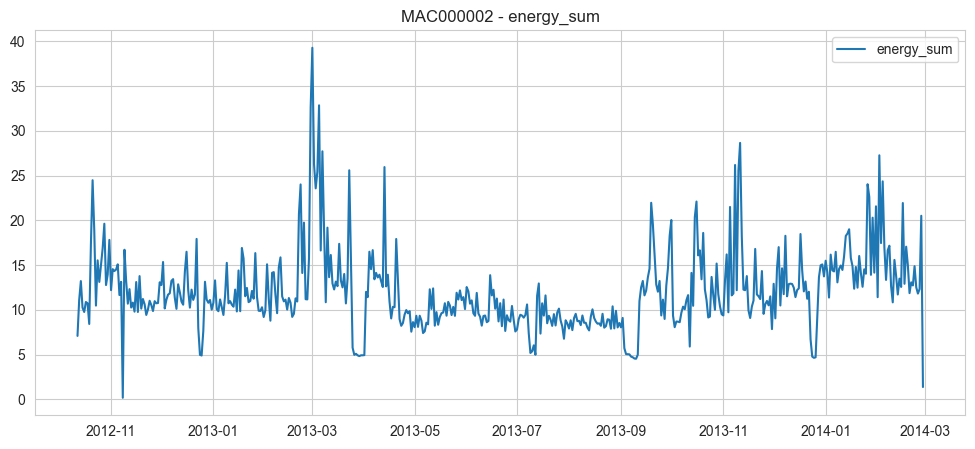

In [34]:
plt.figure(figsize=(12,5))
plt.plot(series, label=series_col)
plt.title(f'{example_id} - {series_col}')
plt.legend()
plt.show()

#### ADF Test for stationarity

In [35]:
def adf_test(ts, title='Series'):
    print(f'== ADF Test: {title} ==')
    ts_clean = ts.dropna()
    res = adfuller(ts_clean)
    print('ADF Statistic: {:.6f}'.format(res[0]))
    print('p-value: {:.6f}'.format(res[1]))
    if res[1] < 0.05:
        print('Stationary (reject null)')
    else:
        print('Non-stationary (fail to reject null)')

adf_test(series[series_col], title=f'{example_id} {series_col}')

== ADF Test: MAC000002 energy_sum ==
ADF Statistic: -5.043178
p-value: 0.000018
Stationary (reject null)


In [ ]:
# no differencing needed since p < 0.05

In [37]:
# --- helper functions ---
def evaluate_forecast(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    # MAPE with tiny epsilon to avoid divide-by-zero
    eps = 1e-8
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps))) * 100
    r2 = r2_score(y_true, y_pred)
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MAPE%': mape, 'R2': r2}

def plot_series_with_forecast(train, test, preds_dict, title=None):
    plt.figure(figsize=(14,5))
    plt.plot(train.index, train, label='Train', linewidth=1)
    plt.plot(test.index, test, label='Test', linewidth=1)
    for name, pred in preds_dict.items():
        plt.plot(pred.index, pred, label=name, linewidth=1)
    plt.legend()
    if title: plt.title(title)
    plt.show()

#### train-test split

In [41]:
# Train-test split
def train_test_split_series(ts, test_size=0.2):
    n = len(ts)
    split = int(np.ceil(n * (1 - test_size)))
    train = ts.iloc[:split]
    test = ts.iloc[split:]
    return train, test

train, test = train_test_split_series(series.dropna(), test_size=0.2)

In [42]:
print("Train length:", len(train), "Test length:", len(test))

Train length: 404 Test length: 101


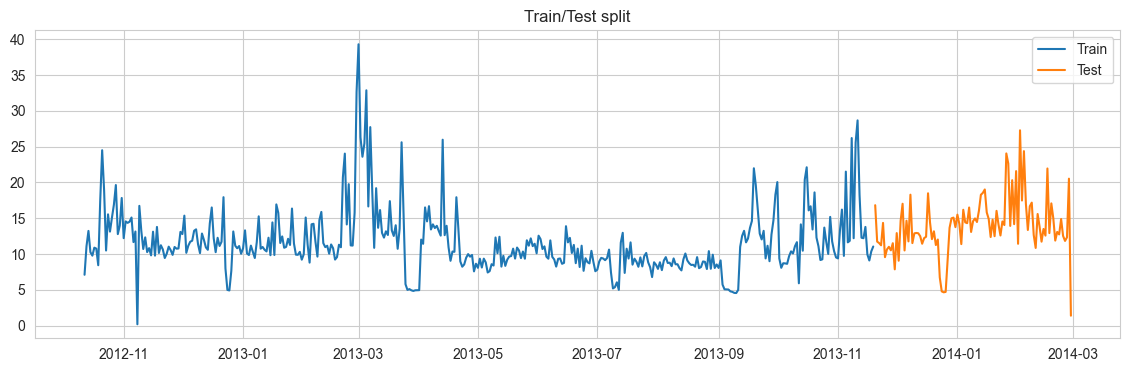

In [43]:
# plot split
plt.figure(figsize=(14,4))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.title('Train/Test split')
plt.legend()
plt.show()

#### model training

In [45]:
# trying
#  - non-seasonal auto_arima (seasonal=False)
#  - seasonal auto_arima with candidate seasonal periods (weekly=7)

In [46]:
print("Running auto_arima (non-seasonal)...")
auto_ns = auto_arima(
    train,
    seasonal=False,
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    max_p=6, max_q=6, max_d=3,
    information_criterion='aic'
)
print("auto_arima (non-seasonal) summary:")
print(auto_ns.summary())

Running auto_arima (non-seasonal)...
auto_arima (non-seasonal) summary:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  404
Model:               SARIMAX(3, 1, 2)   Log Likelihood               -1070.643
Date:                Fri, 17 Oct 2025   AIC                           2153.286
Time:                        16:06:19   BIC                           2177.280
Sample:                    10-12-2012   HQIC                          2162.785
                         - 11-19-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3678      0.099     -3.732      0.000      -0.561      -0.175
ar.L2          0.4887      0.066      7.412      0.000     

In [47]:
try:
    arima_order = auto_ns.order  # (p,d,q)
except Exception:
    # fallback attribute names
    arima_order = getattr(auto_ns, 'order_', None) or getattr(auto_ns, 'get_params', lambda: None)()
print("Suggested ARIMA order (p,d,q):", arima_order)

Suggested ARIMA order (p,d,q): (3, 1, 2)


In [48]:
# auto_arima (seasonal weekly m=7)
print("Running auto_arima with weekly seasonality (m=7). This can take longer...")
auto_s = auto_arima(
    train,
    seasonal=True,
    m=7,
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    max_p=4, max_q=4, max_P=2, max_Q=2, max_d=3, max_D=1,
    information_criterion='aic'
)
print("auto_arima (seasonal m=7) summary:")
print(auto_s.summary())

Running auto_arima with weekly seasonality (m=7). This can take longer...
auto_arima (seasonal m=7) summary:
                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  404
Model:             SARIMAX(2, 1, 3)x(1, 0, [], 7)   Log Likelihood               -1066.150
Date:                            Fri, 17 Oct 2025   AIC                           2148.300
Time:                                    16:11:32   BIC                           2180.292
Sample:                                10-12-2012   HQIC                          2160.966
                                     - 11-19-2013                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
inter

In [49]:
# extract seasonal order
try:
    sarima_order = auto_s.order  # (p,d,q)
    sarima_seasonal_order = auto_s.seasonal_order  # (P,D,Q,m)
except Exception:
    sarima_order = getattr(auto_s, 'order', None) or getattr(auto_s, 'order_', None)
    sarima_seasonal_order = getattr(auto_s, 'seasonal_order', None) or getattr(auto_s, 'seasonal_order_', None)

In [50]:
print("Suggested SARIMA order (p,d,q):", sarima_order)

Suggested SARIMA order (p,d,q): (2, 1, 3)


In [51]:
print("Suggested seasonal_order (P,D,Q,m):", sarima_seasonal_order)

Suggested seasonal_order (P,D,Q,m): (1, 0, 0, 7)


In [52]:
# Fit ARIMA (from auto_arima non-seasonal suggestion) - if auto_arima doesnt return value, fallback =(1,0,1)
if arima_order is None:
    arima_order = (1,0,1)
p,d,q = arima_order
print("Fitting ARIMA", (p,d,q))
arima_model = ARIMA(train, order=(p,d,q))
arima_fit = arima_model.fit()
print(arima_fit.summary())

Fitting ARIMA (3, 1, 2)
                               SARIMAX Results                                
Dep. Variable:             energy_sum   No. Observations:                  404
Model:                 ARIMA(3, 1, 2)   Log Likelihood               -1070.643
Date:                Fri, 17 Oct 2025   AIC                           2153.286
Time:                        16:14:07   BIC                           2177.280
Sample:                    10-12-2012   HQIC                          2162.785
                         - 11-19-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3678      0.099     -3.732      0.000      -0.561      -0.175
ar.L2          0.4887      0.066      7.412      0.000       0.359       0.618
ar.L3          0.2149      0

In [53]:
# Forecast for test horizon
n_forecast = len(test)
arima_forecast = arima_fit.forecast(steps=n_forecast)
# align index
arima_forecast = pd.Series(arima_forecast, index=test.index)

In [54]:
# Fit SARIMA (seasonal) using suggested seasonal_order (weekly) -if auto arima seasonal suggestion missing, fallback =(1,0,1,7) seasonal (P,D,Q,m)
if sarima_order is None or sarima_seasonal_order is None:
    print("Seasonal suggestion not found; falling back to (1,0,1)x(1,0,1,7)")
    sarima_order = (1,0,1)
    sarima_seasonal_order = (1,0,1,7)

p_s,d_s,q_s = sarima_order
P,D,Q,m = sarima_seasonal_order
print("Fitting SARIMA", sarima_order, " seasonal:", sarima_seasonal_order)

Fitting SARIMA (2, 1, 3)  seasonal: (1, 0, 0, 7)


In [55]:
sarima_model = SARIMAX(train,
                       order=(p_s,d_s,q_s),
                       seasonal_order=(P,D,Q,m),
                       enforce_stationarity=False,
                       enforce_invertibility=False)
sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                         energy_sum   No. Observations:                  404
Model:             SARIMAX(2, 1, 3)x(1, 0, [], 7)   Log Likelihood               -1048.048
Date:                            Fri, 17 Oct 2025   AIC                           2110.095
Time:                                    16:14:34   BIC                           2137.930
Sample:                                10-12-2012   HQIC                          2121.125
                                     - 11-19-2013                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0935      0.135     -0.690      0.490      -0.359       0.172
ar.L2          0.6182      0.086   

#### forecasts

In [56]:
sarima_forecast = sarima_fit.get_forecast(steps=n_forecast).predicted_mean
sarima_forecast = pd.Series(sarima_forecast, index=test.index)

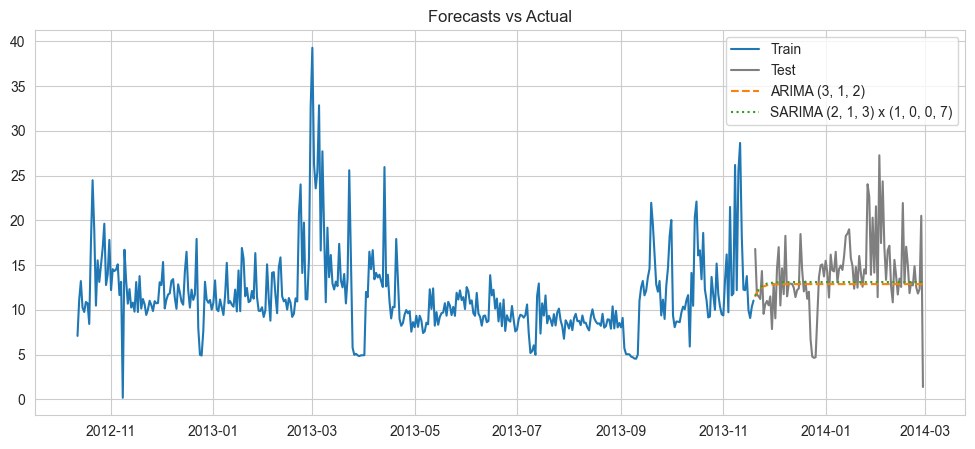

In [57]:
# forecasts vs actual
plt.figure(figsize=(12,5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test', color='tab:gray')
plt.plot(arima_forecast.index, arima_forecast, label=f'ARIMA {arima_order}', linestyle='--')
plt.plot(sarima_forecast.index, sarima_forecast, label=f'SARIMA {sarima_order} x {sarima_seasonal_order}', linestyle=':')
plt.legend()
plt.title('Forecasts vs Actual')
plt.show()

#### evaluation metrics (MSE, RMSE, MAE, MAPE, R2) for both models

In [58]:
metrics_arima = evaluate_forecast(test, arima_forecast)
metrics_sarima = evaluate_forecast(test, sarima_forecast)

print("ARIMA metrics:", metrics_arima)
print("SARIMA metrics:", metrics_sarima)

ARIMA metrics: {'MSE': 17.137432197219912, 'RMSE': 4.139738179791074, 'MAE': 2.858811623514503, 'MAPE%': 29.684866871563653, 'R2': -0.07145544751756239}
SARIMA metrics: {'MSE': 16.69013879683715, 'RMSE': 4.085356630312359, 'MAE': 2.828341045178848, 'MAPE%': 29.97234481160428, 'R2': -0.04349005894805957}


#### Residual diagnostics: residual plots, ACF, and Ljung-Box (lag 10)

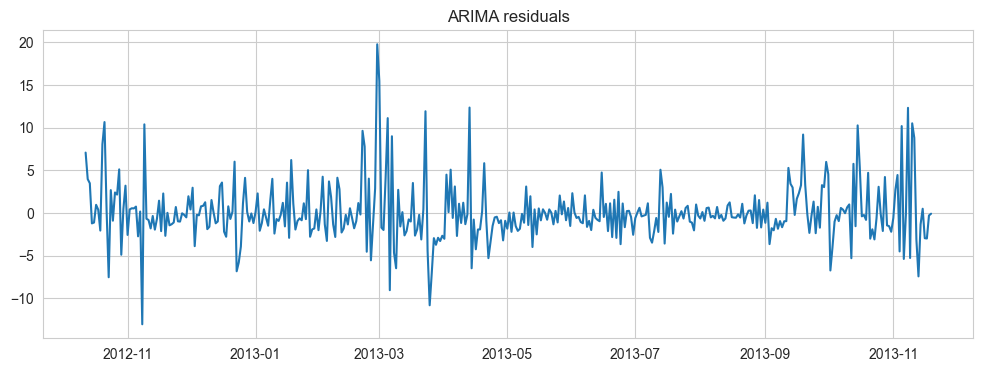

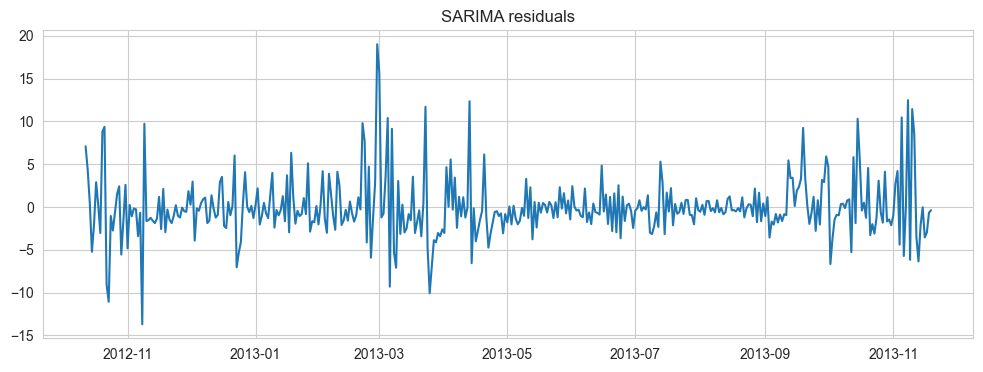

<Figure size 1200x400 with 0 Axes>

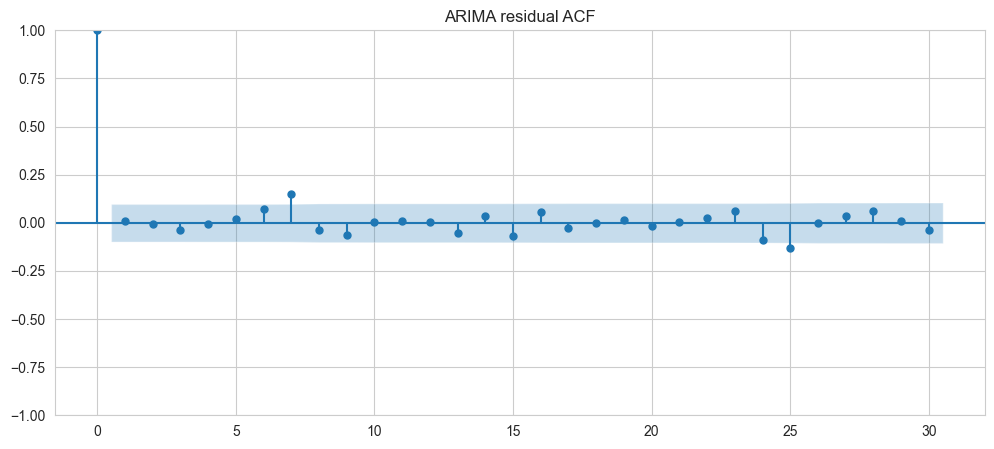

<Figure size 1200x400 with 0 Axes>

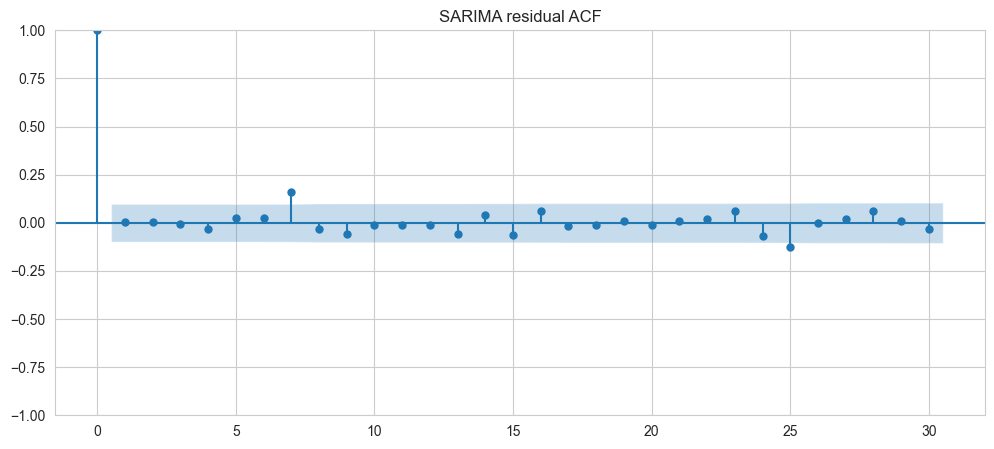

ARIMA Ljung-Box (lag=10):
      lb_stat  lb_pvalue
10  14.441083   0.153806

SARIMA Ljung-Box (lag=10):
      lb_stat  lb_pvalue
10  13.219969   0.211632


In [59]:
resid_arima = arima_fit.resid.dropna()
resid_sarima = sarima_fit.resid.dropna()

# Residual time series
plt.figure(figsize=(12,4))
plt.plot(resid_arima)
plt.title('ARIMA residuals')
plt.show()

plt.figure(figsize=(12,4))
plt.plot(resid_sarima)
plt.title('SARIMA residuals')
plt.show()

# ACF of residuals
plt.figure(figsize=(12,4))
plot_acf(resid_arima, lags=30, title='ARIMA residual ACF')
plt.show()

plt.figure(figsize=(12,4))
plot_acf(resid_sarima, lags=30, title='SARIMA residual ACF')
plt.show()

# Ljung-Box test (common choice: lag 10)
lb_arima = acorr_ljungbox(resid_arima, lags=[10], return_df=True)
lb_sarima = acorr_ljungbox(resid_sarima, lags=[10], return_df=True)

print("ARIMA Ljung-Box (lag=10):")
print(lb_arima)
print("\nSARIMA Ljung-Box (lag=10):")
print(lb_sarima)

In [60]:
print("\nFINAL REPORT")
print("ARIMA order:", arima_order, "-> metrics:", metrics_arima)
print("SARIMA order:", sarima_order, "seasonal:", sarima_seasonal_order, "-> metrics:", metrics_sarima)


FINAL REPORT
ARIMA order: (3, 1, 2) -> metrics: {'MSE': 17.137432197219912, 'RMSE': 4.139738179791074, 'MAE': 2.858811623514503, 'MAPE%': 29.684866871563653, 'R2': -0.07145544751756239}
SARIMA order: (2, 1, 3) seasonal: (1, 0, 0, 7) -> metrics: {'MSE': 16.69013879683715, 'RMSE': 4.085356630312359, 'MAE': 2.828341045178848, 'MAPE%': 29.97234481160428, 'R2': -0.04349005894805957}


| Metric / fit                       | ARIMA(3,1,2) |           SARIMA(2,1,3)(1,0,0,7) |
| ---------------------------------- | -----------: | -------------------------------: |
| Log Likelihood                     |    -1070.643 | **-1048.048** (higher is better) |
| AIC                                |     2153.286 |    **2110.095** (lower = better) |
| BIC                                |     2177.280 |    **2137.930** (lower = better) |
| sigma² (residual var)              |      11.8462 |   **9.8613** (smaller is better) |
| Test MSE                           |      17.1374 |                      **16.6901** |
| Test RMSE                          |       4.1397 |                       **4.0854** |
| Test MAE                           |       2.8588 |                       **2.8283** |
| Test MAPE                          |  **29.685%** |                          29.972% |
| Test R²                            |      -0.0715 |                      **-0.0435** |
| Ljung-Box (lag=10) p-value (resid) |       0.1538 |                           0.2116 |


##### Verdict (overall fit): SARIMA is better by information criteria (AIC/BIC), log-likelihood, and slightly better on MSE/RMSE/MAE and residual variance. 
##### ARIMA has marginally lower MAPE and slightly worse R². 
##### Residual autocorrelation tests (Ljung-Box) show no evidence of remaining autocorrelation for either model (p > 0.05) — that’s good.

##### Bottom line: SARIMA is statistically better (AIC/BIC, slightly better RMSE/MSE), but neither model provides strong predictive performance (MAPE ~30%, negative R²)

================================================================================================================

================================================================================================================

## Prophet

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [19]:
csv_path = r"C:\Users\LOQ\Downloads\smart meter\daily_dataset.csv"
df = pd.read_csv(csv_path)

In [20]:
df.head(3)

,LCLid,day,energy_median,energy_mean,energy_max,energy_count,energy_std,energy_sum,energy_min
0,MAC000131,2011-12-15,0.4850,0.432045,0.868,22,0.239146,9.505,0.072
1,MAC000131,2011-12-16,0.1415,0.296167,1.116,48,0.281471,14.216,0.031
2,MAC000131,2011-12-17,0.1015,0.189812,0.685,48,0.188405,9.111,0.064


In [21]:
print("\nColumns:", df.columns.tolist())


Columns: ['LCLid', 'day', 'energy_median', 'energy_mean', 'energy_max', 'energy_count', 'energy_std', 'energy_sum', 'energy_min']


In [22]:
print("Initial shape:", df.shape)

Initial shape: (3510433, 9)


#### Preprocessing

In [23]:
# 'day' to datetime
df['day'] = pd.to_datetime(df['day'])

In [24]:
# Check nulls
print("\nMissing values per column:")
print(df.isna().sum())


Missing values per column:
LCLid                0
day                  0
energy_median       30
energy_mean         30
energy_max          30
energy_count         0
energy_std       11331
energy_sum          30
energy_min          30
dtype: int64


In [25]:
numeric_cols = [
    'energy_median', 'energy_mean', 'energy_max',
    'energy_count', 'energy_std', 'energy_sum', 'energy_min'
]

# Sort by ID and date
df = df.sort_values(['LCLid', 'day'])

In [26]:
# Fill missing values within each LCLid
for col in numeric_cols:
    df[col] = df.groupby('LCLid')[col].transform(lambda g: g.ffill().bfill())

In [27]:
# Fill any remaining missing std with group mean
df['energy_std'] = df.groupby('LCLid')['energy_std'].transform(lambda g: g.fillna(g.mean()))

In [28]:
print("\nNulls after cleaning:")
print(df[numeric_cols].isna().sum())


Nulls after cleaning:
energy_median    5
energy_mean      5
energy_max       5
energy_count     0
energy_std       5
energy_sum       5
energy_min       5
dtype: int64


In [29]:
# Drop any still-missing rows
df = df.dropna(subset=numeric_cols)

In [30]:
print("\nNulls after cleaning:")
print(df[numeric_cols].isna().sum())


Nulls after cleaning:
energy_median    0
energy_mean      0
energy_max       0
energy_count     0
energy_std       0
energy_sum       0
energy_min       0
dtype: int64


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3510428 entries, 2037924 to 2815756
Data columns (total 9 columns):
 #   Column         Dtype         
---  ------         -----         
 0   LCLid          object        
 1   day            datetime64[ns]
 2   energy_median  float64       
 3   energy_mean    float64       
 4   energy_max     float64       
 5   energy_count   int64         
 6   energy_std     float64       
 7   energy_sum     float64       
 8   energy_min     float64       
dtypes: datetime64[ns](1), float64(6), int64(1), object(1)
memory usage: 267.8+ MB


In [31]:
# selecting One Meter 
meter_id = "MAC000002"
df_meter = df[df['LCLid'] == meter_id].copy()

In [33]:
print(f"\nMeter {meter_id} -> {len(df_meter)} records from {df_meter['day'].min()} to {df_meter['day'].max()}")


Meter MAC000002 -> 505 records from 2012-10-12 00:00:00 to 2014-02-28 00:00:00


#### preparing Data for Prophet

In [34]:
prophet_df = df_meter[['day', 'energy_sum']].rename(columns={'day': 'ds', 'energy_sum': 'y'})
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])

In [35]:
# Ensure daily continuity
prophet_df = prophet_df.set_index('ds').asfreq('D')
prophet_df['y'] = prophet_df['y'].interpolate()
prophet_df = prophet_df.reset_index()

#### Train-Test Split (last 60 days test)

In [36]:
train = prophet_df.iloc[:-60]
test = prophet_df.iloc[-60:]

print(f"Train: {len(train)} | Test: {len(test)}")

Train: 445 | Test: 60


#### DAILY PROPHET MODEL

In [37]:
model_daily = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    seasonality_mode='additive'
)
model_daily.fit(train)

21:42:50 - cmdstanpy - INFO - Chain [1] start processing
21:42:51 - cmdstanpy - INFO - Chain [1] done processing


In [38]:
# Forecast 
future_daily = model_daily.make_future_dataframe(periods=60, freq='D')
forecast_daily = model_daily.predict(future_daily)

In [39]:
# Daily Forecast Evaluation
y_true = test['y'].values
y_pred = forecast_daily.set_index('ds').loc[test['ds'], 'yhat'].values

In [40]:
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2 = r2_score(y_true, y_pred)

metrics_daily = {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MAPE%': mape, 'R2': r2}

print("\n--- DAILY Prophet Evaluation ---")
for k, v in metrics_daily.items():
    print(f"{k}: {v:.4f}")


--- DAILY Prophet Evaluation ---
MSE: 35.6703
RMSE: 5.9725
MAE: 4.3853
MAPE%: 49.9119
R2: -1.3143


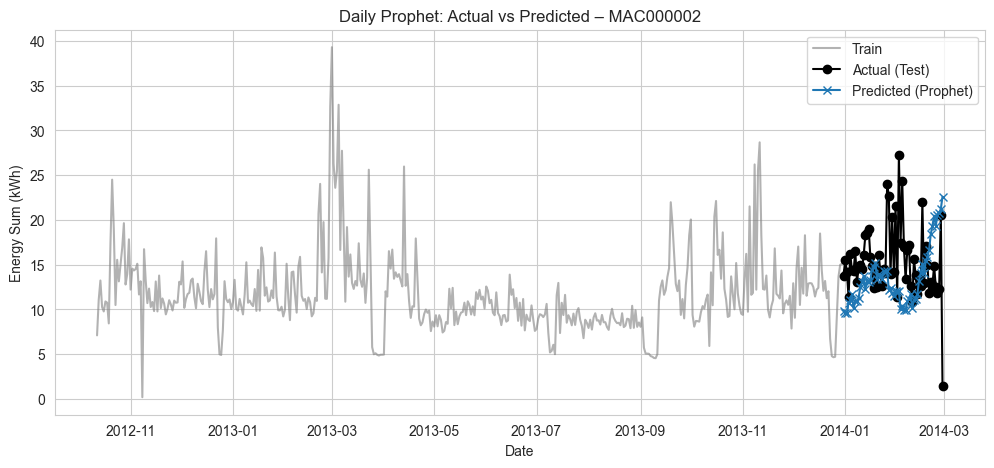

In [51]:
# Actual vs Predicted (DAILY)
plt.figure(figsize=(12, 5))
plt.plot(train['ds'], train['y'], label='Train', color='gray', alpha=0.6)
plt.plot(test['ds'], y_true, label='Actual (Test)', color='black', marker='o')
plt.plot(test['ds'], y_pred, label='Predicted (Prophet)', color='tab:blue', marker='x')
plt.title(f"Daily Prophet: Actual vs Predicted – {meter_id}")
plt.xlabel("Date")
plt.ylabel("Energy Sum (kWh)")
plt.legend()
plt.grid(True)
plt.show()

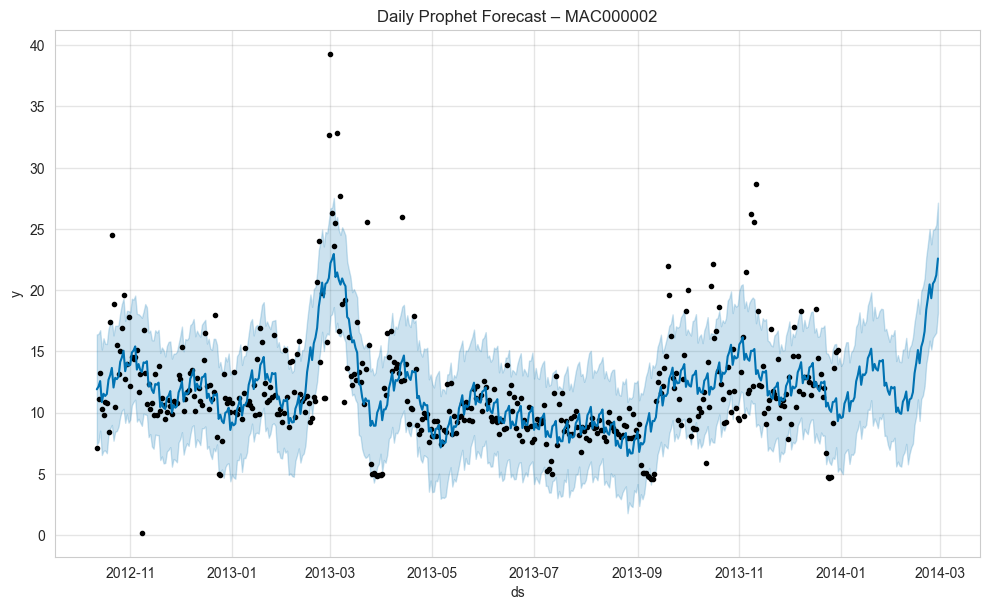

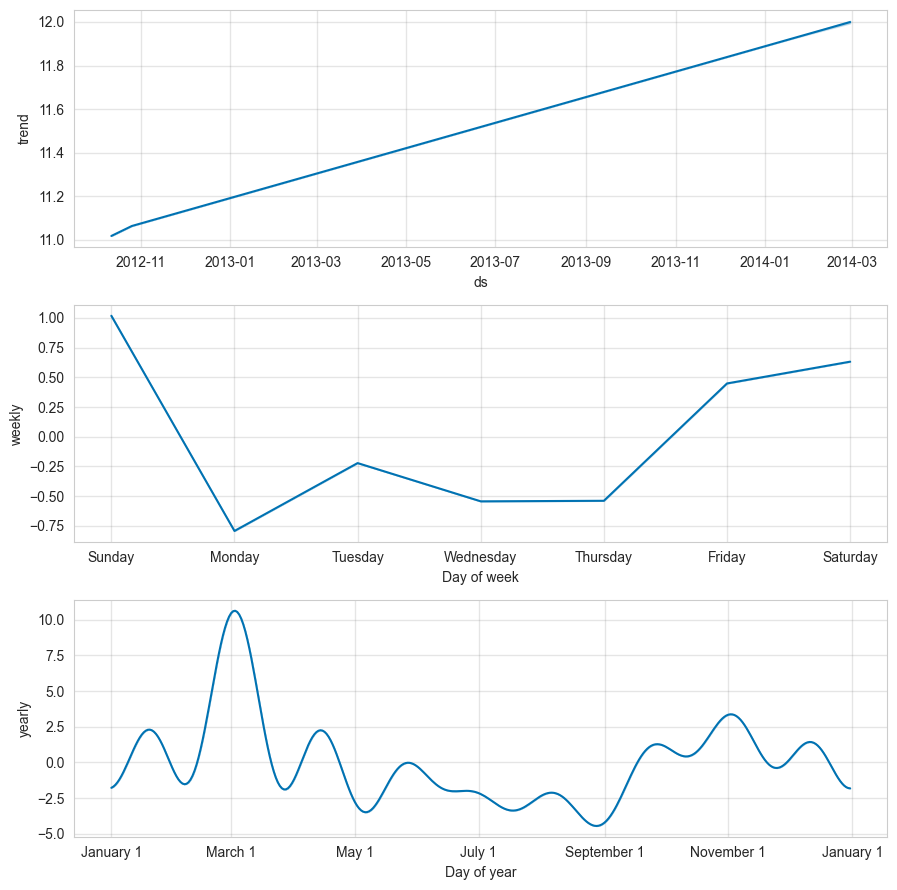

In [41]:
# Daily Forecast Visualization
model_daily.plot(forecast_daily)
plt.title(f"Daily Prophet Forecast – {meter_id}")
plt.show()

model_daily.plot_components(forecast_daily)
plt.show()

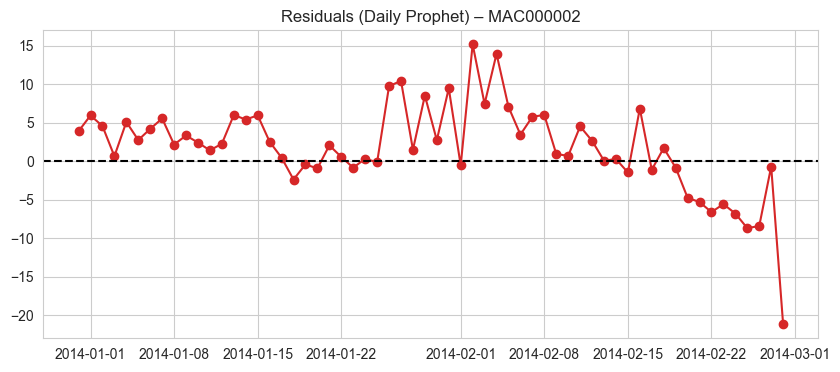

In [42]:
# Residual diagnostics
residuals = y_true - y_pred
plt.figure(figsize=(10, 4))
plt.plot(test['ds'], residuals, marker='o', color='tab:red')
plt.title(f"Residuals (Daily Prophet) – {meter_id}")
plt.axhline(0, color='black', linestyle='--')
plt.show()

#### WEEKLY PROPHET MODEL

In [43]:
# resamplin to weekly sums
prophet_weekly = prophet_df.resample('W', on='ds').sum().reset_index()

# Split
train_w = prophet_weekly.iloc[:-8]
test_w = prophet_weekly.iloc[-8:]

In [44]:
model_weekly = Prophet(
    daily_seasonality=False,
    weekly_seasonality=False,
    yearly_seasonality=True,
    seasonality_mode='additive'
)
model_weekly.fit(train_w)


21:44:38 - cmdstanpy - INFO - Chain [1] start processing
21:44:38 - cmdstanpy - INFO - Chain [1] done processing


In [45]:
# --- Forecast ---
future_weekly = model_weekly.make_future_dataframe(periods=8, freq='W')
forecast_weekly = model_weekly.predict(future_weekly)

In [46]:
y_true_w = test_w['y'].values
y_pred_w = forecast_weekly.set_index('ds').loc[test_w['ds'], 'yhat'].values

In [47]:
mse_w = mean_squared_error(y_true_w, y_pred_w)
rmse_w = np.sqrt(mse_w)
mae_w = mean_absolute_error(y_true_w, y_pred_w)
mape_w = np.mean(np.abs((y_true_w - y_pred_w) / y_true_w)) * 100
r2_w = r2_score(y_true_w, y_pred_w)

metrics_weekly = {'MSE': mse_w, 'RMSE': rmse_w, 'MAE': mae_w, 'MAPE%': mape_w, 'R2': r2_w}

print("\n--- WEEKLY Prophet Evaluation ---")
for k, v in metrics_weekly.items():
    print(f"{k}: {v:.4f}")


--- WEEKLY Prophet Evaluation ---
MSE: 1742.8880
RMSE: 41.7479
MAE: 29.7046
MAPE%: 36.2698
R2: -3.3723


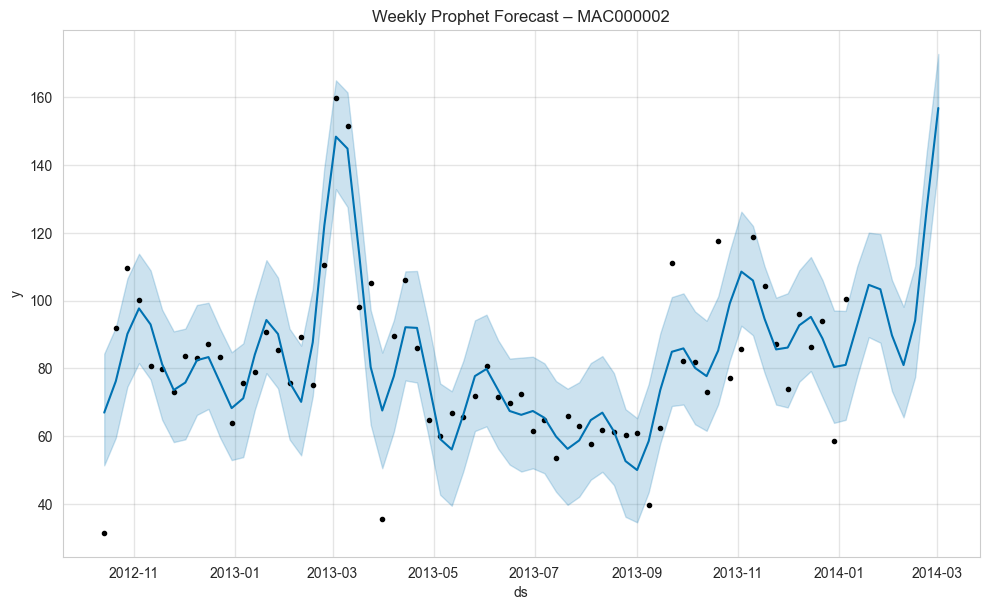

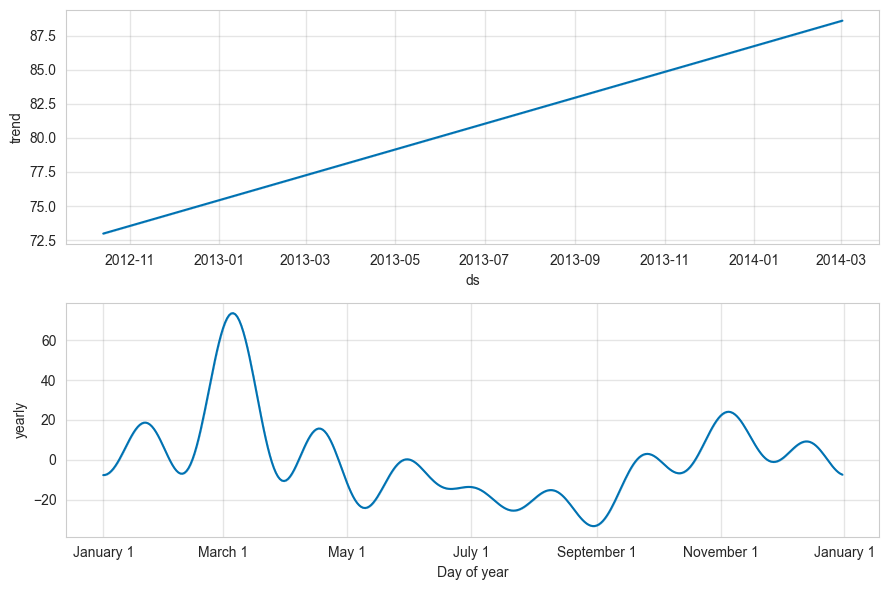

In [48]:
#Weekly Visualization & Diagnostics
model_weekly.plot(forecast_weekly)
plt.title(f"Weekly Prophet Forecast – {meter_id}")
plt.show()

model_weekly.plot_components(forecast_weekly)
plt.show()

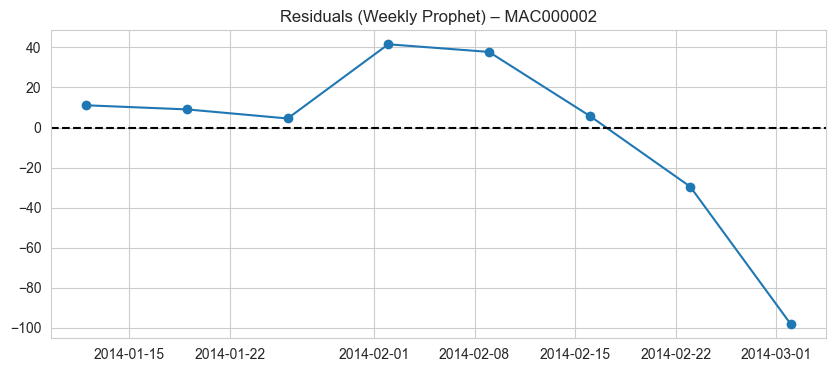

In [49]:
residuals_w = y_true_w - y_pred_w
plt.figure(figsize=(10, 4))
plt.plot(test_w['ds'], residuals_w, marker='o', color='tab:blue')
plt.title(f"Residuals (Weekly Prophet) – {meter_id}")
plt.axhline(0, color='black', linestyle='--')
plt.show()

In [50]:
# 🧾 13. Final Comparison
print(f"FINAL PROPHET COMPARISON – {meter_id}")
print("DAILY MODEL METRICS:")
for k, v in metrics_daily.items():
    print(f"  {k}: {v:.4f}")

print("\nWEEKLY MODEL METRICS:")
for k, v in metrics_weekly.items():
    print(f"  {k}: {v:.4f}")

FINAL PROPHET COMPARISON – MAC000002
DAILY MODEL METRICS:
  MSE: 35.6703
  RMSE: 5.9725
  MAE: 4.3853
  MAPE%: 49.9119
  R2: -1.3143

WEEKLY MODEL METRICS:
  MSE: 1742.8880
  RMSE: 41.7479
  MAE: 29.7046
  MAPE%: 36.2698
  R2: -3.3723


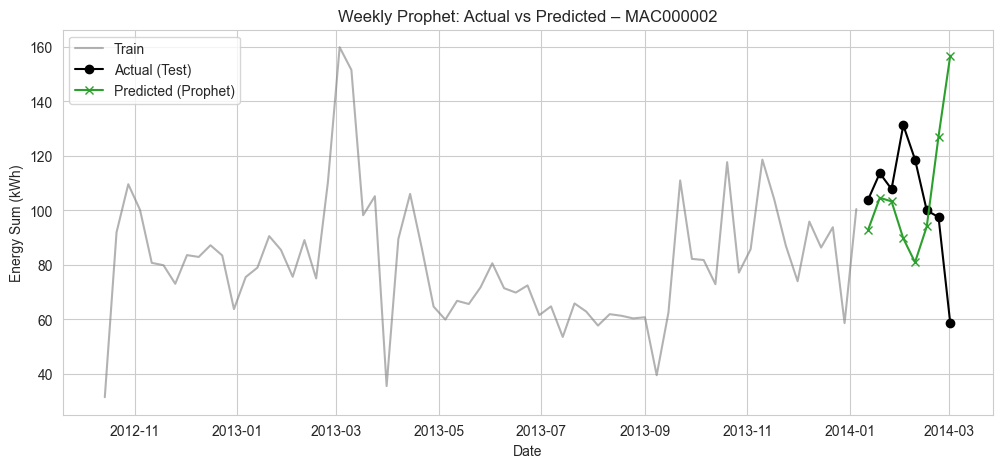

In [52]:
# Actual vs Predicted (WEEKLY)
plt.figure(figsize=(12, 5))
plt.plot(train_w['ds'], train_w['y'], label='Train', color='gray', alpha=0.6)
plt.plot(test_w['ds'], y_true_w, label='Actual (Test)', color='black', marker='o')
plt.plot(test_w['ds'], y_pred_w, label='Predicted (Prophet)', color='tab:green', marker='x')
plt.title(f"Weekly Prophet: Actual vs Predicted – {meter_id}")
plt.xlabel("Date")
plt.ylabel("Energy Sum (kWh)")
plt.legend()
plt.grid(True)
plt.show()

| Model                       | Type             | MSE         | RMSE      | MAE   | MAPE (%)  | R²        | Notes                                    |
| --------------------------- | ---------------- | ----------- | --------- | ----- | --------- | --------- | ---------------------------------------- |
| **ARIMA (3,1,2)**           | Daily            | **17.14**   | **4.14**  | 2.86  | **29.68** | **-0.07** | Baseline non-seasonal                    |
| **SARIMA (2,1,3)(1,0,0,7)** | Daily (seasonal) | **16.69**   | **4.09**  | 2.83  | **29.97** | **-0.04** | Slightly better; captures weekly pattern |
| **Prophet (daily)**         | Daily            | **35.67**   | **5.97**  | 4.39  | **49.91** | **-1.31** | Worse accuracy, higher residual error    |
| **Prophet (weekly)**        | Weekly           | **1742.89** | **41.75** | 29.70 | **36.27** | **-3.37** | Very poor; weekly aggregation too coarse |


==============================================================================================================

==============================================================================================================

#### XGBoost (Gradient Boosting)

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

In [54]:
csv_path = r"C:\Users\LOQ\Downloads\smart meter\daily_dataset.csv"
df = pd.read_csv(csv_path)

In [55]:
# to datetime and sort
df['day'] = pd.to_datetime(df['day'])
df = df.sort_values(['LCLid', 'day'])

In [56]:
# numeric columns
numeric_cols = [
    'energy_median', 'energy_mean', 'energy_max',
    'energy_count', 'energy_std', 'energy_sum', 'energy_min'
]

# Forward/back fill missing numeric values by meter
for col in numeric_cols:
    df[col] = df.groupby('LCLid')[col].transform(lambda g: g.ffill().bfill())

In [57]:
# Drop any remaining nulls
df = df.dropna(subset=numeric_cols)
print("Remaining nulls after cleaning:")
print(df[numeric_cols].isna().sum())

Remaining nulls after cleaning:
energy_median    0
energy_mean      0
energy_max       0
energy_count     0
energy_std       0
energy_sum       0
energy_min       0
dtype: int64


In [58]:
print("\nData shape:", df.shape)
print("Unique meters:", df['LCLid'].nunique())


Data shape: (3510428, 9)
Unique meters: 5561


In [60]:
df['LCLid'][0]

'MAC000131'

In [61]:
meter_id = 'MAC000002'   # choose one example meter
df_meter = df[df['LCLid'] == meter_id].copy()

In [63]:
df_meter

,LCLid,day,energy_median,energy_mean,energy_max,energy_count,energy_std,energy_sum,energy_min
2037924,MAC000002,2012-10-12,0.1385,0.154304,0.886,46,0.196034,7.098,0.000
2037925,MAC000002,2012-10-13,0.1800,0.230979,0.933,48,0.192329,11.087,0.076
2037926,MAC000002,2012-10-14,0.1580,0.275479,1.085,48,0.274647,13.223,0.070
2037927,MAC000002,2012-10-15,0.1310,0.213688,1.164,48,0.224483,10.257,0.070
2037928,MAC000002,2012-10-16,0.1450,0.203521,0.991,48,0.184115,9.769,0.087
...,...,...,...,...,...,...,...,...,...
2038424,MAC000002,2014-02-24,0.1345,0.261000,0.891,48,0.205853,12.528,0.075
2038425,MAC000002,2014-02-25,0.1925,0.246375,0.802,48,0.166291,11.826,0.075
2038426,MAC000002,2014-02-26,0.1515,0.256833,1.028,48,0.196095,12.328,0.076
2038427,MAC000002,2014-02-27,0.2180,0.427458,1.350,48,0.406681,20.518,0.080


In [64]:
df_meter = df_meter[['day', 'energy_sum']].sort_values('day').reset_index(drop=True)
print(f"Series length: {len(df_meter)}, range: {df_meter['day'].min()} to {df_meter['day'].max()}")

Series length: 505, range: 2012-10-12 00:00:00 to 2014-02-28 00:00:00


#### DAILY MODEL

In [65]:
# Feature Engineering (for Daily)

# Lag features (previous 7 days)
for lag in range(1, 8):
    df_meter[f'lag_{lag}'] = df_meter['energy_sum'].shift(lag)

# Rolling mean and std (window 7)
df_meter['roll_mean_7'] = df_meter['energy_sum'].shift(1).rolling(window=7).mean()
df_meter['roll_std_7'] = df_meter['energy_sum'].shift(1).rolling(window=7).std()

# Date-time features
df_meter['dayofweek'] = df_meter['day'].dt.dayofweek
df_meter['month'] = df_meter['day'].dt.month
df_meter['is_weekend'] = df_meter['dayofweek'].isin([5,6]).astype(int)

In [66]:
# dropping na rows after lag creation
df_meter = df_meter.dropna().reset_index(drop=True)
print("Final daily dataset shape:", df_meter.shape)

Final daily dataset shape: (498, 14)


In [67]:
# Train-Test Split
split_idx = int(len(df_meter) * 0.8)
train = df_meter.iloc[:split_idx]
test = df_meter.iloc[split_idx:]

X_train = train.drop(['day', 'energy_sum'], axis=1)
y_train = train['energy_sum']
X_test = test.drop(['day', 'energy_sum'], axis=1)
y_test = test['energy_sum']

print(f"Train size: {len(train)}, Test size: {len(test)}")

Train size: 398, Test size: 100


In [71]:
# XGBoost Model training (for Daily)

xgb_daily = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_daily.fit(X_train, y_train);

In [72]:
y_pred_daily = xgb_daily.predict(X_test)

In [73]:
# Evaluation (for Daily)
def evaluate(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MAPE%': mape, 'R2': r2}

metrics_daily = evaluate(y_test, y_pred_daily)

In [74]:
print("XGBoost DAILY model metrics:")
for k,v in metrics_daily.items():
    print(f"{k}: {v:.4f}")

XGBoost DAILY model metrics:
MSE: 15.8193
RMSE: 3.9773
MAE: 2.9699
MAPE%: 31.3264
R2: 0.0156


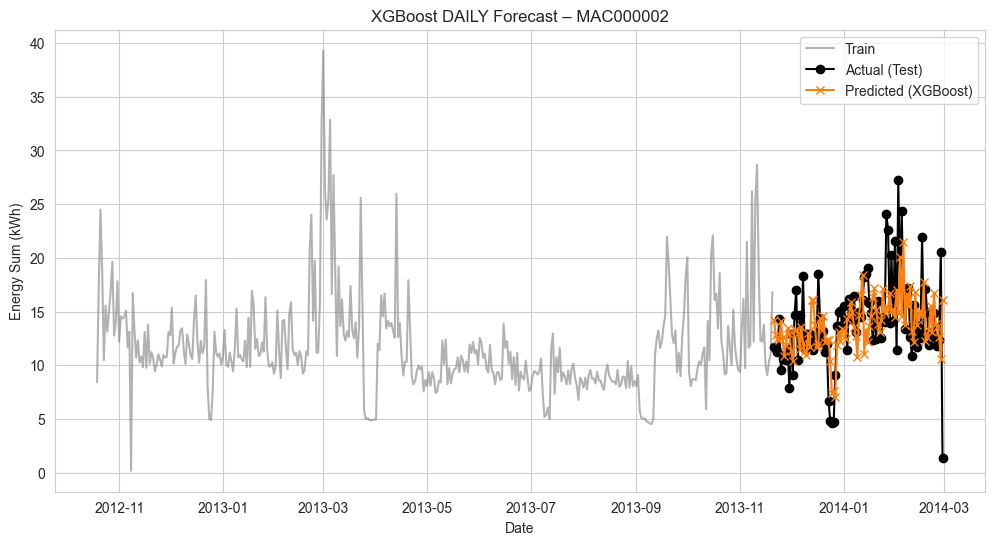

In [75]:
# Actual vs Predicted plot (for Daily)
plt.figure(figsize=(12,6))
plt.plot(train['day'], train['energy_sum'], label='Train', color='gray', alpha=0.6)
plt.plot(test['day'], y_test, label='Actual (Test)', color='black', marker='o')
plt.plot(test['day'], y_pred_daily, label='Predicted (XGBoost)', color='tab:orange', marker='x')
plt.title(f"XGBoost DAILY Forecast – {meter_id}")
plt.xlabel("Date")
plt.ylabel("Energy Sum (kWh)")
plt.legend()
plt.grid(True)
plt.show()

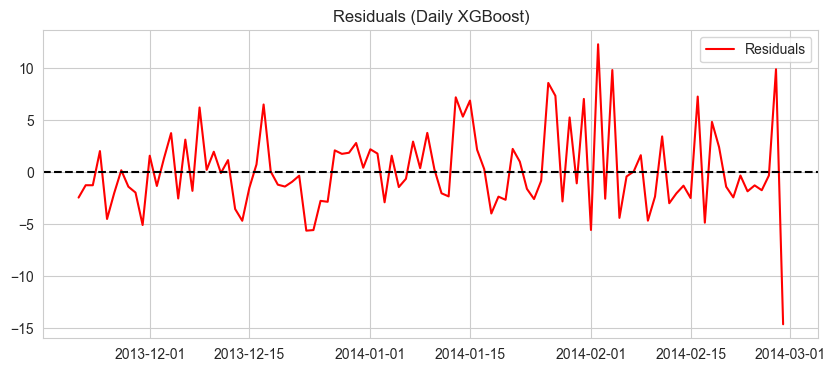

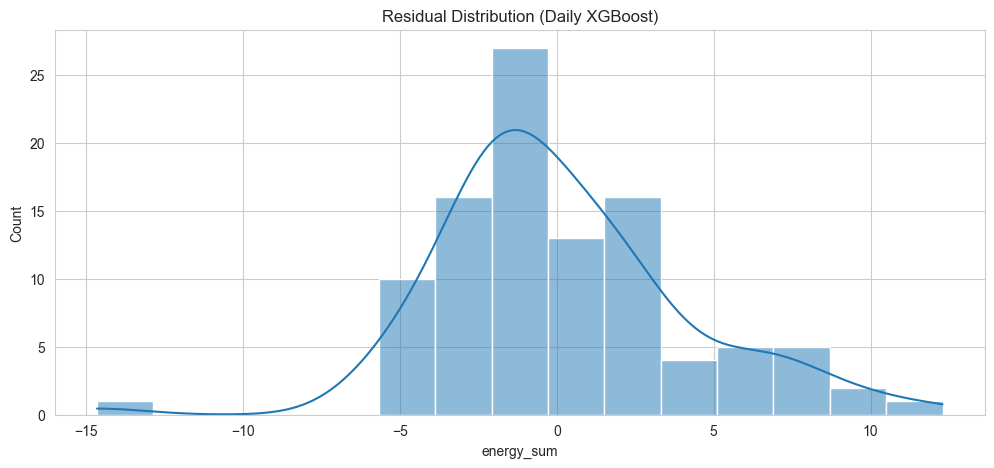

In [76]:
# resdiual analysis (for Daily)
residuals = y_test - y_pred_daily

plt.figure(figsize=(10,4))
plt.plot(test['day'], residuals, label='Residuals', color='red')
plt.axhline(0, color='black', linestyle='--')
plt.title("Residuals (Daily XGBoost)")
plt.legend()
plt.grid(True)
plt.show()

sns.histplot(residuals, kde=True)
plt.title("Residual Distribution (Daily XGBoost)")
plt.show()

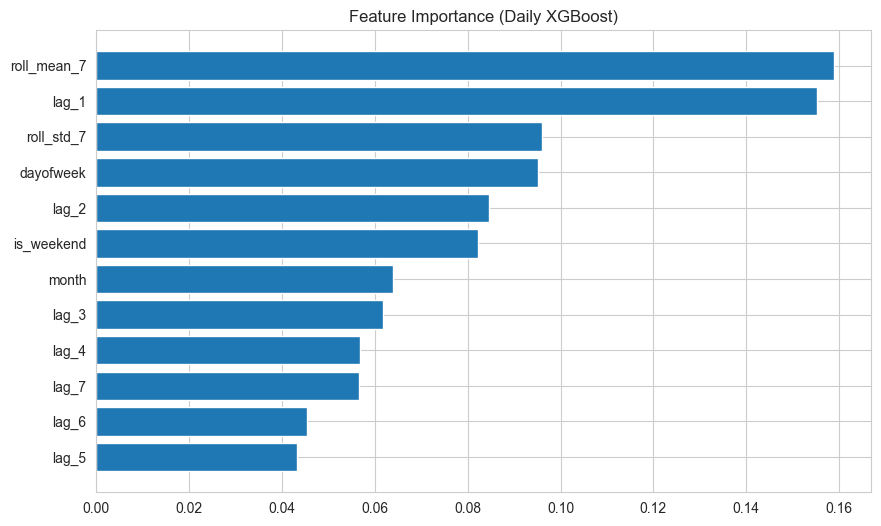

In [77]:
# Feature Importance (for Daily)
importances = xgb_daily.feature_importances_
sorted_idx = np.argsort(importances)
plt.figure(figsize=(10,6))
plt.barh(X_train.columns[sorted_idx], importances[sorted_idx])
plt.title("Feature Importance (Daily XGBoost)")
plt.show()

#### WEEKLY MODEL

In [78]:
df_weekly = df_meter[['day', 'energy_sum']].copy()
df_weekly = df_weekly.resample('W-MON', on='day').sum().reset_index().sort_values('day')

# Lag and rolling features (4 weeks)
for lag in range(1, 5):
    df_weekly[f'lag_{lag}'] = df_weekly['energy_sum'].shift(lag)
df_weekly['roll_mean_4'] = df_weekly['energy_sum'].shift(1).rolling(window=4).mean()
df_weekly['roll_std_4'] = df_weekly['energy_sum'].shift(1).rolling(window=4).std()

# Time features
df_weekly['month'] = df_weekly['day'].dt.month
df_weekly['weekofyear'] = df_weekly['day'].dt.isocalendar().week.astype(int)

In [79]:
df_weekly = df_weekly.dropna().reset_index(drop=True)
print("Weekly dataset shape:", df_weekly.shape)

Weekly dataset shape: (68, 10)


In [80]:
# Train-Test Split (foor Weekly)
split_idx_w = int(len(df_weekly) * 0.8)
train_w = df_weekly.iloc[:split_idx_w]
test_w = df_weekly.iloc[split_idx_w:]

X_train_w = train_w.drop(['day', 'energy_sum'], axis=1)
y_train_w = train_w['energy_sum']
X_test_w = test_w.drop(['day', 'energy_sum'], axis=1)
y_test_w = test_w['energy_sum']

print(f"Train size (weekly): {len(train_w)}, Test size: {len(test_w)}")

Train size (weekly): 54, Test size: 14


In [81]:
xgb_weekly = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_weekly.fit(X_train_w, y_train_w);

In [82]:
y_pred_weekly = xgb_weekly.predict(X_test_w)
metrics_weekly = evaluate(y_test_w, y_pred_weekly)
print("XGBoost WEEKLY model metrics:")
for k,v in metrics_weekly.items():
    print(f"{k}: {v:.4f}")

XGBoost WEEKLY model metrics:
MSE: 482.7173
RMSE: 21.9708
MAE: 17.0564
MAPE%: 22.2044
R2: -0.1343


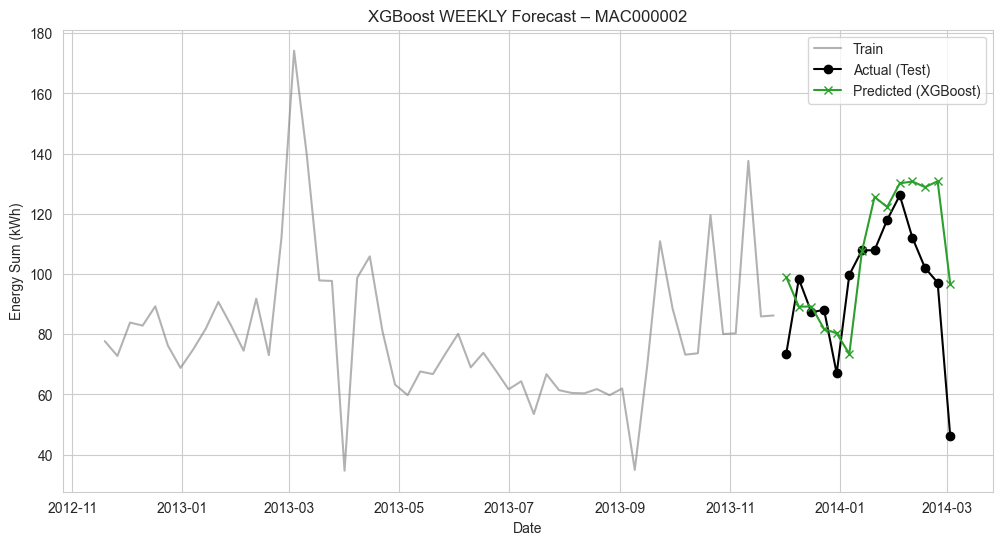

In [83]:
# Actual vs Predicted plot (for Weekly)
plt.figure(figsize=(12,6))
plt.plot(train_w['day'], train_w['energy_sum'], label='Train', color='gray', alpha=0.6)
plt.plot(test_w['day'], y_test_w, label='Actual (Test)', color='black', marker='o')
plt.plot(test_w['day'], y_pred_weekly, label='Predicted (XGBoost)', color='tab:green', marker='x')
plt.title(f"XGBoost WEEKLY Forecast – {meter_id}")
plt.xlabel("Date")
plt.ylabel("Energy Sum (kWh)")
plt.legend()
plt.grid(True)
plt.show()

In [88]:
y_test_pred = xgb_daily.predict(X_test)
residuals = y_test - y_test_pred
print("Mean residual:", np.mean(residuals))
print("Std residual:", np.std(residuals))
print("Min residual:", np.min(residuals))
print("Max residual:", np.max(residuals))


Mean residual: 0.13608075728009134
Std residual: 3.975015976797601
Min residual: -14.65284260559082
Max residual: 12.293787843432618


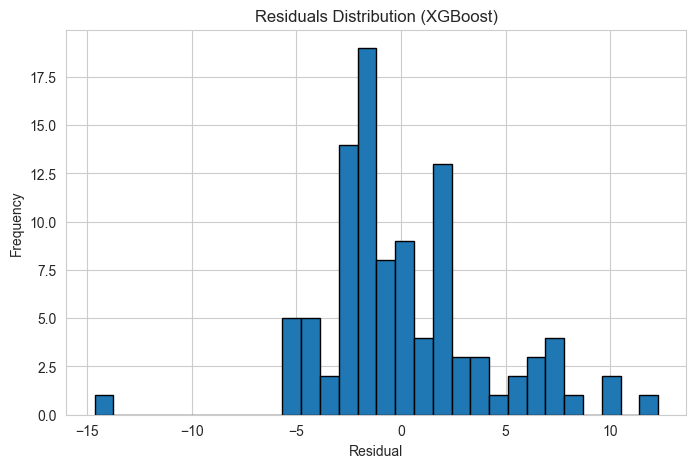

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(residuals, bins=30, edgecolor='black')
plt.title("Residuals Distribution (XGBoost)")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()


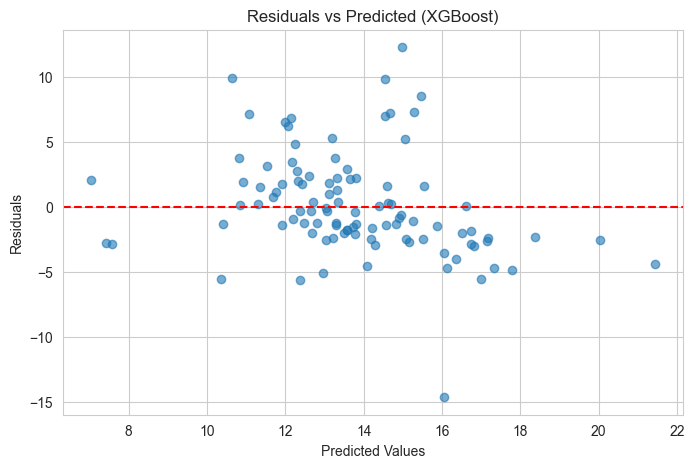

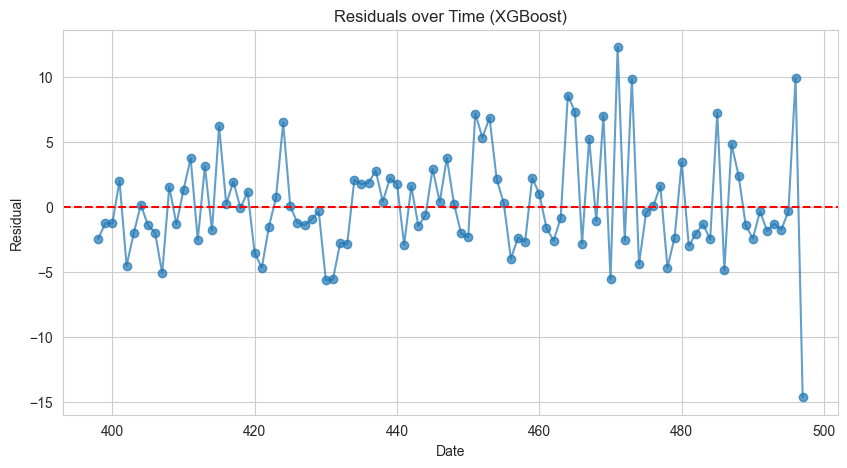

In [91]:
plt.figure(figsize=(8,5))
plt.scatter(y_test_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Predicted (XGBoost)")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

plt.figure(figsize=(10,5))
plt.plot(y_test.index, residuals, marker='o', linestyle='-', alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals over Time (XGBoost)")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.show()


In [86]:
print("="*40)
print(f"FINAL XGBOOST COMPARISON – {meter_id}")
print("="*40)
print("DAILY MODEL METRICS:")
for k,v in metrics_daily.items():
    print(f"  {k}: {v:.4f}")

print("\nWEEKLY MODEL METRICS:")
for k,v in metrics_weekly.items():
    print(f"  {k}: {v:.4f}")

FINAL XGBOOST COMPARISON – MAC000002
DAILY MODEL METRICS:
  MSE: 15.8193
  RMSE: 3.9773
  MAE: 2.9699
  MAPE%: 31.3264
  R2: 0.0156

WEEKLY MODEL METRICS:
  MSE: 482.7173
  RMSE: 21.9708
  MAE: 17.0564
  MAPE%: 22.2044
  R2: -0.1343


==============================================================================================================

#### statistical and ML baseline models comparison

| **Model**                   | **Type / Frequency**   |   **MSE** | **RMSE** |  **MAE** | **MAPE (%)** |    **R²** | **Remarks / Interpretation**                                       |
| --------------------------- | ---------------------- | --------: | -------: | -------: | -----------: | --------: | ------------------------------------------------------------------ |
| **ARIMA (3,1,2)**           | Daily (non-seasonal)   | **17.14** | **4.14** |     2.86 |        29.68 |     -0.07 | Baseline ARIMA; captures short-term trend but weak generalization. |
| **SARIMA (2,1,3)(1,0,0,7)** | Daily (seasonal)       | **16.69** | **4.09** |     2.83 |        29.97 |     -0.04 | Slightly better than ARIMA; weekly seasonality helps marginally.   |
| **Prophet (Daily)**         | Daily (additive trend) |     35.67 |     5.97 |     4.39 |        49.91 |     -1.31 | Overfits long-term trend; underperforms on short-term variation.   |
| **Prophet (Weekly)**        | Weekly aggregated      |   1742.89 |    41.75 |    29.70 |        36.27 |     -3.37 | Very poor — weekly aggregation loses variability and pattern.      |
| **XGBoost (Daily)**         | Daily (ML-based)       | **15.82** | **3.98** | **2.97** |    **31.33** | **0.016** | Best performing overall; learns nonlinear relations effectively.   |
| **XGBoost (Weekly)**        | Weekly aggregated      |    482.72 |    21.97 |    17.06 |        22.20 |     -0.13 | Acceptable but worse due to small weekly sample size.              |


xgboost (daily) was best performer

prophet (weekly) was worst performer

==============================================================================================================

In [93]:
#### next models

#### LSTM (Long Short-Term Memory)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from statsmodels.graphics.tsaplots import plot_acf
import warnings
warnings.filterwarnings("ignore")

# random seeds
import tensorflow as tf
np.random.seed(42)
tf.random.set_seed(42)

In [2]:
df = pd.read_csv(r"C:\Users\LOQ\Downloads\smart meter\daily_dataset.csv", parse_dates=['day'])

In [3]:
df = df.sort_values(by=['LCLid', 'day'])
df.head()

,LCLid,day,energy_median,energy_mean,energy_max,energy_count,energy_std,energy_sum,energy_min
2037924,MAC000002,2012-10-12,0.1385,0.154304,0.886,46,0.196034,7.098,0.000
2037925,MAC000002,2012-10-13,0.1800,0.230979,0.933,48,0.192329,11.087,0.076
2037926,MAC000002,2012-10-14,0.1580,0.275479,1.085,48,0.274647,13.223,0.070
2037927,MAC000002,2012-10-15,0.1310,0.213688,1.164,48,0.224483,10.257,0.070
2037928,MAC000002,2012-10-16,0.1450,0.203521,0.991,48,0.184115,9.769,0.087


In [4]:
meter_id = "MAC000002"
df_meter = df[df['LCLid'] == meter_id].copy()
df_meter = df_meter[['day', 'energy_sum']].rename(columns={'day': 'ds', 'energy_sum': 'y'})
df_meter = df_meter.set_index('ds').asfreq('D')

In [5]:
df_meter['y'] = df_meter['y'].interpolate()  # handle missing

In [6]:
df_meter

,y
ds,
2012-10-12,7.098
2012-10-13,11.087
2012-10-14,13.223
2012-10-15,10.257
2012-10-16,9.769
...,...
2014-02-24,12.528
2014-02-25,11.826
2014-02-26,12.328


In [7]:
# Data scaling and splitting 
def preprocess_data(df, window_size=30):
    values = df['y'].values.reshape(-1, 1)
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled = scaler.fit_transform(values)
    
    train_size = int(len(scaled) * 0.8)
    train, test = scaled[:train_size], scaled[train_size:]
    
    def create_sequences(data, window_size):
        X, y = [], []
        for i in range(window_size, len(data)):
            X.append(data[i-window_size:i])
            y.append(data[i])
        return np.array(X), np.array(y)
    
    X_train, y_train = create_sequences(train, window_size)
    X_test, y_test = create_sequences(test, window_size)
    
    print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
    return X_train, y_train, X_test, y_test, scaler

In [8]:
def build_lstm_model(input_shape):
    model = Sequential([
        LSTM(32, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(16),
        Dense(8, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

In [9]:
# Model training & eval 
def train_lstm_model(model, X_train, y_train, epochs=25, batch_size=64):
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    history = model.fit(
        X_train, y_train,
        validation_split=0.1,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[es],
        verbose=1
    )
    return model, history

def evaluate_model(model, X_test, y_test, scaler):
    # handle missing or too-small test set
    if X_test is None or X_test.shape[0] == 0:
        print("Not enough test samples — skipping evaluation.")
        return None, None, {
            'MSE': np.nan,
            'RMSE': np.nan,
            'MAE': np.nan,
            'MAPE (%)': np.nan,
            'R2': np.nan
        }

    y_pred_scaled = model.predict(X_test, verbose=0)
    y_test_inv = scaler.inverse_transform(y_test)
    y_pred_inv = scaler.inverse_transform(y_pred_scaled)
    mse = mean_squared_error(y_test_inv, y_pred_inv)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_inv, y_pred_inv)
    mape = np.mean(np.abs((y_test_inv - y_pred_inv) / y_test_inv)) * 100
    r2 = r2_score(y_test_inv, y_pred_inv)

    return y_test_inv, y_pred_inv, {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE (%)': mape,
        'R2': r2
    }

def plot_results(y_test_inv, y_pred_inv, freq_label, meter_id):
    plt.figure(figsize=(10, 5))
    plt.plot(y_test_inv, label='Actual', color='blue')
    plt.plot(y_pred_inv, label='Predicted', color='orange')
    plt.title(f"LSTM Forecasting ({freq_label}) - {meter_id}")
    plt.xlabel("Time Steps")
    plt.ylabel("Energy Consumption")
    plt.legend()
    plt.show()

In [10]:
def plot_residuals(y_test_inv, y_pred_inv, freq_label):
    if y_test_inv is None or y_pred_inv is None:
        print(f"No residuals to plot for {freq_label}.")
        return

    residuals = y_test_inv.flatten() - y_pred_inv.flatten()

    # Histogram
    plt.figure(figsize=(8, 4))
    sns.histplot(residuals, kde=True)
    plt.title(f"Residual Distribution ({freq_label})")
    plt.show()

    # Safe number of lags
    max_lags = min(40, len(residuals) // 2)
    if max_lags < 2:
        print(f"Not enough residuals for ACF plot ({len(residuals)} samples).")
        return

    plot_acf(residuals, lags=max_lags)
    plt.title(f"ACF of Residuals ({freq_label})")
    plt.show()

In [26]:
def run_lstm_pipeline(df, freq_label='daily', window_size=30, epochs=10, batch_size=32):
    print(f"\nRunning LSTM for {freq_label.upper()} data")
    X_train, y_train, X_test, y_test, scaler = preprocess_data(df, window_size)
    model = build_lstm_model((X_train.shape[1], 1))
    model, history = train_lstm_model(model, X_train, y_train, epochs, batch_size)
    y_test_inv, y_pred_inv, metrics = evaluate_model(model, X_test, y_test, scaler)

    print("\nMODEL METRICS:")
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}")

    plot_results(y_test_inv, y_pred_inv, freq_label, meter_id)
    plot_residuals(y_test_inv, y_pred_inv, freq_label)

    return {
        'Model': f'LSTM ({freq_label})',
        **metrics
    }


Running LSTM for DAILY data
Train shape: (374, 30, 1), Test shape: (71, 30, 1)
Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 135ms/step - loss: 0.0897 - val_loss: 0.0833
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0344 - val_loss: 0.0181
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0166 - val_loss: 0.0218
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0123 - val_loss: 0.0238
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0121 - val_loss: 0.0195
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0117 - val_loss: 0.0209
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0116 - val_loss: 0.0208

MODEL METRICS:
  MSE: 18.6184
  RMSE: 4.3149
  MAE: 3.2024
  MAPE (%): 40.6900
  R2: 0.0266


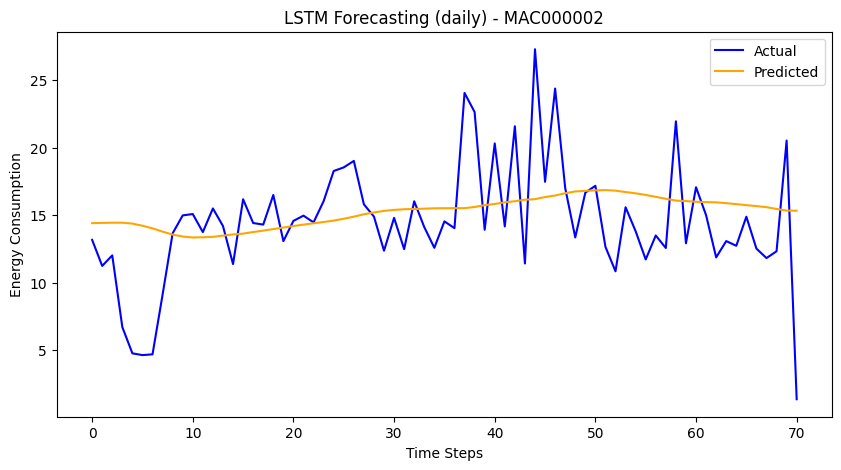

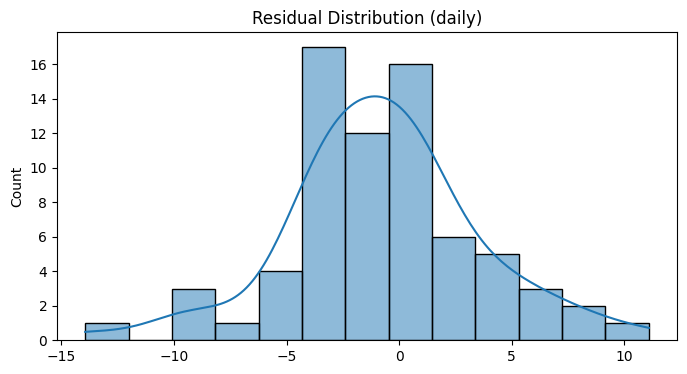

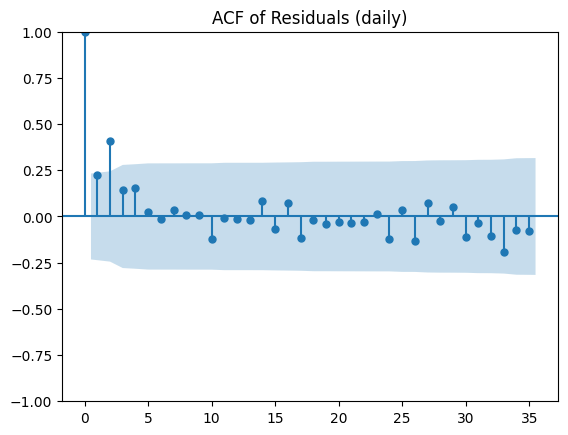

In [27]:
# daily model
daily_results = run_lstm_pipeline(df_meter, freq_label='daily', epochs=10, batch_size=32)

In [28]:
daily_results

{'Model': 'LSTM (daily)',
 'MSE': 18.618369254160843,
 'RMSE': 4.31490083943546,
 'MAE': 3.2024234674058514,
 'MAPE (%)': 40.69002584919421,
 'R2': 0.02658521799503033}


Running LSTM for WEEKLY data
Train shape: (55, 3, 1), Test shape: (12, 3, 1)
Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 518ms/step - loss: 0.1589 - val_loss: 0.2544
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 0.1473 - val_loss: 0.2370
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 0.1357 - val_loss: 0.2169
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.1218 - val_loss: 0.1966
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.1084 - val_loss: 0.1761
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0956 - val_loss: 0.1554
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0813 - val_loss: 0.1344
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.0690 - val_loss: 0.1135
Epoch 9/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.0572 - val_loss: 0.0930
Epoch 10/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 0.0478 - val_loss: 0.0737

MODEL METRICS:
  MSE: 1272.2077
  RMSE: 35.6680
  MAE: 32.4943
  MAPE (%): 31.4875
  R2:

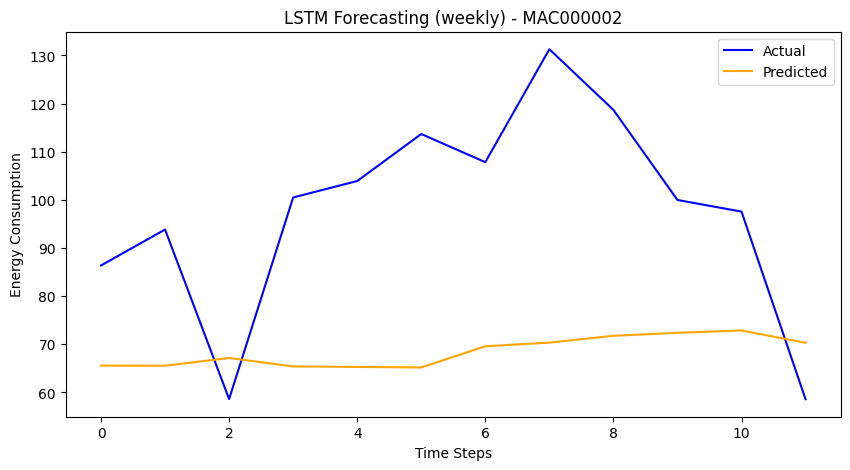

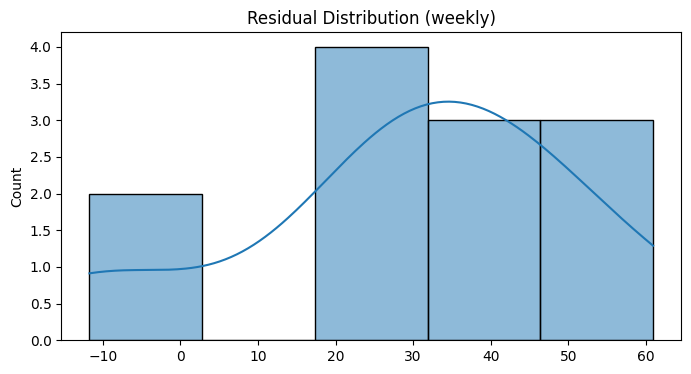

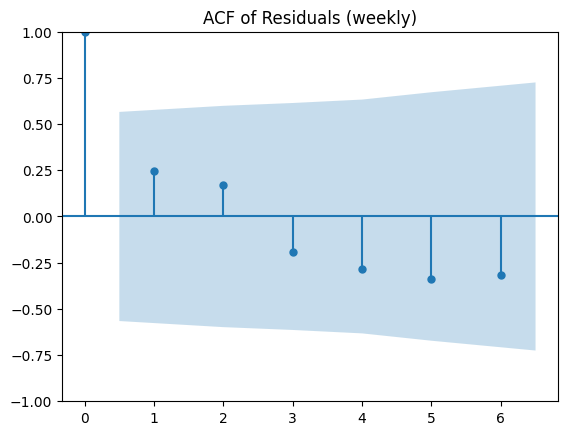

In [29]:
# weekly model
df_weekly = df_meter.resample('W').sum()
weekly_results = run_lstm_pipeline(df_weekly, freq_label='weekly', window_size=3, epochs=10, batch_size=24)

In [30]:
weekly_results

{'Model': 'LSTM (weekly)',
 'MSE': 1272.2077307453244,
 'RMSE': 35.66802112180215,
 'MAE': 32.49430972203776,
 'MAPE (%)': 31.487500747396073,
 'R2': -1.9478985239835889}

==============================================================================================================

#### XGBoost–LSTM (Hybrid)

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
np.random.seed(42)
tf.random.set_seed(42)

In [32]:
df = pd.read_csv(r"C:\Users\LOQ\Downloads\smart meter\daily_dataset.csv", parse_dates=['day'])
df = df.sort_values(by=['LCLid', 'day'])

meter_id = "MAC000002"
df_meter = df[df['LCLid'] == meter_id].copy()
df_meter = df_meter[['day', 'energy_sum']].rename(columns={'day': 'ds', 'energy_sum': 'y'})
df_meter = df_meter.set_index('ds').asfreq('D')
df_meter['y'] = df_meter['y'].interpolate()

In [33]:
# Scaling + Sequence Creation
def make_sequences(df, window_size=30, split_ratio=0.8):
    values = df['y'].values.reshape(-1, 1)
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(values)

    train_size = int(len(scaled) * split_ratio)
    train, test = scaled[:train_size], scaled[train_size:]

    def create_seq(data):
        X, y = [], []
        for i in range(window_size, len(data)):
            X.append(data[i-window_size:i])
            y.append(data[i])
        return np.array(X), np.array(y)

    X_train, y_train = create_seq(train)
    X_test, y_test = create_seq(test)
    return X_train, y_train, X_test, y_test, scaler

In [48]:
# training Base LSTM Model
def train_lstm(X_train, y_train, window_size, epochs=10, batch_size=48):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(window_size, 1)),
        Dropout(0.2),
        LSTM(32),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    history = model.fit(
        X_train, y_train,
        validation_split=0.1,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[es],
        verbose=1
    )
    return model

In [49]:
def train_xgboost_lstm(X_train, y_train, X_test, y_test, model_lstm, scaler):
    # Get LSTM predictions
    y_train_pred_lstm = model_lstm.predict(X_train, verbose=0)
    y_test_pred_lstm = model_lstm.predict(X_test, verbose=0)

    # Flatten inputs for XGBoost
    X_train_flat = X_train.reshape(X_train.shape[0], -1)
    X_test_flat = X_test.reshape(X_test.shape[0], -1)

    # Add LSTM pred as an extra feature
    X_train_xgb = np.hstack((X_train_flat, y_train_pred_lstm))
    X_test_xgb = np.hstack((X_test_flat, y_test_pred_lstm))

    # Train XGBoost on residuals
    residual_train = y_train - y_train_pred_lstm

    xgb_model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    xgb_model.fit(X_train_xgb, residual_train.ravel())

    # Predict residuals and combine
    residual_pred = xgb_model.predict(X_test_xgb).reshape(-1, 1)
    y_pred_hybrid_scaled = y_test_pred_lstm + residual_pred
    y_pred_hybrid_inv = scaler.inverse_transform(y_pred_hybrid_scaled)
    y_test_inv = scaler.inverse_transform(y_test)

    # Metrics
    mse = mean_squared_error(y_test_inv, y_pred_hybrid_inv)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_inv, y_pred_hybrid_inv)
    r2 = r2_score(y_test_inv, y_pred_hybrid_inv)
    mape = np.mean(np.abs((y_test_inv - y_pred_hybrid_inv) / y_test_inv)) * 100

    metrics = {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MAPE (%)': mape, 'R2': r2}
    return y_test_inv, y_pred_hybrid_inv, metrics


In [52]:
# Hybrid Model (Daily)
window_size = 30
X_train, y_train, X_test, y_test, scaler = make_sequences(df_meter, window_size)

lstm_model = train_lstm(X_train, y_train, window_size)
y_test_inv, y_pred_hybrid_inv, metrics_daily = train_xgboost_lstm(
    X_train, y_train, X_test, y_test, lstm_model, scaler
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 227ms/step - loss: 0.0476 - val_loss: 0.0237
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0206 - val_loss: 0.0272
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.0140 - val_loss: 0.0233
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.0118 - val_loss: 0.0188
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0125 - val_loss: 0.0217
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.0117 - val_loss: 0.0215
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 0.0115 - val_loss: 0.0198
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.0113 - val_loss: 0.0209
Epoch 9/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 0.0112 - val_loss: 0.0208



DAILY RESULTS:
MSE: 22.2788
RMSE: 4.7200
MAE: 3.3829
MAPE (%): 33.3238
R2: -0.1648


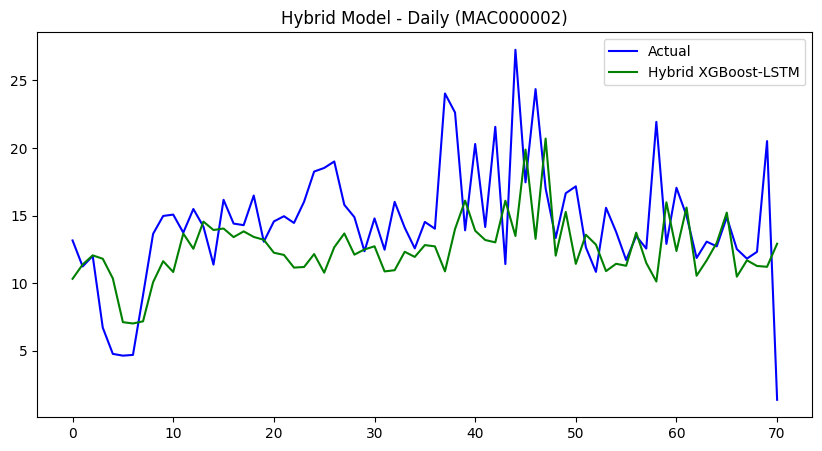

In [53]:
print("\nDAILY RESULTS:")
for k, v in metrics_daily.items():
    print(f"{k}: {v:.4f}")

plt.figure(figsize=(10,5))
plt.plot(y_test_inv, label='Actual', color='blue')
plt.plot(y_pred_hybrid_inv, label='Hybrid XGBoost-LSTM', color='green')
plt.title(f"Hybrid Model - Daily ({meter_id})")
plt.legend()
plt.show()

In [24]:
# Hybrid Model (Weekly)
print("==== WEEKLY HYBRID MODEL ====")
df_weekly = df_meter.resample('W').sum()

window_size = 3  # smaller window for weekly
X_train, y_train, X_test, y_test, scaler = make_sequences(df_weekly, window_size)

lstm_model_weekly = train_lstm(X_train, y_train, window_size, epochs=15, batch_size=16)
y_test_inv_w, y_pred_hybrid_inv_w, metrics_weekly = train_xgboost_lstm(
    X_train, y_train, X_test, y_test, lstm_model_weekly, scaler
)

==== WEEKLY HYBRID MODEL ====
Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 367ms/step - loss: 0.1576 - val_loss: 0.2394
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.1337 - val_loss: 0.1994
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.1073 - val_loss: 0.1568
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.0805 - val_loss: 0.1131
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.0540 - val_loss: 0.0712
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0353 - val_loss: 0.0382
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0265 - val_loss: 0.0233
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0322 - val_loss: 0.0219
Epoch 9/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0356 - val_loss: 0.0226
Epoch 10/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.0311 - val_loss: 0.0268
Epoch 11/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0277 - val_loss: 0.0327
Epoch 12/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - lo


WEEKLY RESULTS:
MSE: 468.2867
RMSE: 21.6399
MAE: 17.4452
MAPE (%): 18.7268
R2: -0.0851


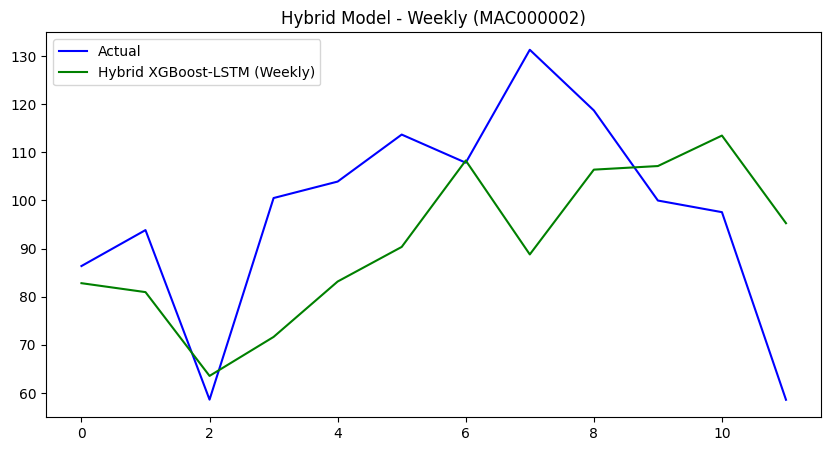

In [25]:
print("\nWEEKLY RESULTS:")
for k, v in metrics_weekly.items():
    print(f"{k}: {v:.4f}")

plt.figure(figsize=(10,5))
plt.plot(y_test_inv_w, label='Actual', color='blue')
plt.plot(y_pred_hybrid_inv_w, label='Hybrid XGBoost-LSTM (Weekly)', color='green')
plt.title(f"Hybrid Model - Weekly ({meter_id})")
plt.legend()
plt.show()

==============================================================================================================

#### ARIMA–XGBoost (Hybrid)

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings("ignore")

import statsmodels.api as sm
np.random.seed(42)

In [55]:
df = pd.read_csv(r"C:\Users\LOQ\Downloads\smart meter\daily_dataset.csv", parse_dates=['day'])
df = df.sort_values(by=['LCLid', 'day'])

meter_id = "MAC000002"
df_meter = df[df['LCLid'] == meter_id].copy()
df_meter = df_meter[['day', 'energy_sum']].rename(columns={'day': 'ds', 'energy_sum': 'y'})
df_meter = df_meter.set_index('ds').asfreq('D')
df_meter['y'] = df_meter['y'].interpolate()

In [56]:
# Train–Test Split (Daily)
train_size = int(len(df_meter) * 0.8)
train, test = df_meter.iloc[:train_size], df_meter.iloc[train_size:]
print(f"Train size: {len(train)}, Test size: {len(test)}")

Train size: 404, Test size: 101


In [57]:
# ARIMA Model
p, d, q = 2, 1, 2
arima_model = ARIMA(train['y'], order=(p, d, q))
arima_result = arima_model.fit()

# Forecast on train + test
train_pred = arima_result.predict(start=train.index[0], end=train.index[-1], dynamic=False)
test_pred = arima_result.predict(start=test.index[0], end=test.index[-1], dynamic=False)

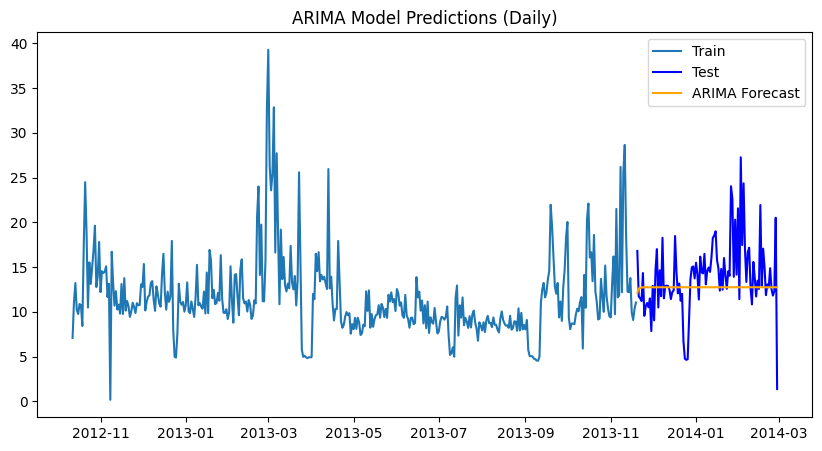

In [58]:
# ARIMA-only predictions
plt.figure(figsize=(10,5))
plt.plot(train.index, train['y'], label='Train')
plt.plot(test.index, test['y'], label='Test', color='blue')
plt.plot(test.index, test_pred, label='ARIMA Forecast', color='orange')
plt.title("ARIMA Model Predictions (Daily)")
plt.legend()
plt.show()

In [59]:
# Residuals = actual - ARIMA prediction
train_residuals = train['y'] - train_pred
test_residuals = test['y'] - test_pred

In [60]:
# lag features for supervised learning
def create_lag_features(series, n_lags=7):
    df_lag = pd.DataFrame(series)
    for i in range(1, n_lags+1):
        df_lag[f'lag_{i}'] = df_lag['y'].shift(i)
    return df_lag.dropna()

train_lags = create_lag_features(train[['y']], n_lags=7)
test_lags = create_lag_features(test[['y']], n_lags=7)

In [61]:
# Align residuals and lagged features
train_resid = train_residuals[-len(train_lags):]
test_resid = test_residuals[-len(test_lags):]

X_train, y_train = train_lags.drop('y', axis=1).values, train_resid.values
X_test, y_test = test_lags.drop('y', axis=1).values, test_resid.values

In [62]:
# training XGBoost on Residuals
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)
residual_pred = xgb_model.predict(X_test)

In [63]:
# combining so that Final prediction = ARIMA prediction + residual correction.
final_pred = test_pred[-len(residual_pred):] + residual_pred

# Eval
y_true = test['y'].iloc[-len(final_pred):].values

In [64]:
mse = mean_squared_error(y_true, final_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, final_pred)
r2 = r2_score(y_true, final_pred)
mape = np.mean(np.abs((y_true - final_pred) / y_true)) * 100

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MAPE (%): {mape:.2f}")
print(f"R2: {r2:.4f}")

MSE: 23.9467
RMSE: 4.8935
MAE: 3.5908
MAPE (%): 34.92
R2: -0.4451


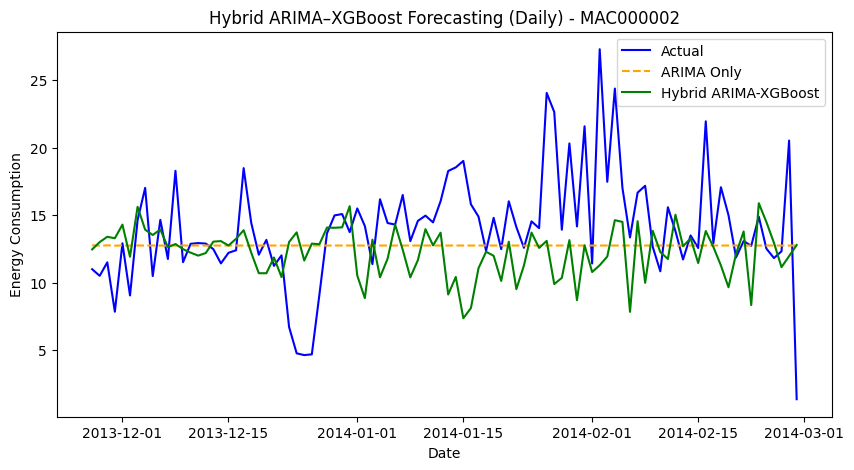

In [65]:
# actual vs predicted 
plt.figure(figsize=(10,5))
plt.plot(test.index[-len(final_pred):], y_true, label='Actual', color='blue')
plt.plot(test.index[-len(final_pred):], test_pred[-len(final_pred):], label='ARIMA Only', color='orange', linestyle='--')
plt.plot(test.index[-len(final_pred):], final_pred, label='Hybrid ARIMA-XGBoost', color='green')
plt.title(f"Hybrid ARIMA–XGBoost Forecasting (Daily) - {meter_id}")
plt.xlabel("Date")
plt.ylabel("Energy Consumption")
plt.legend()
plt.show()

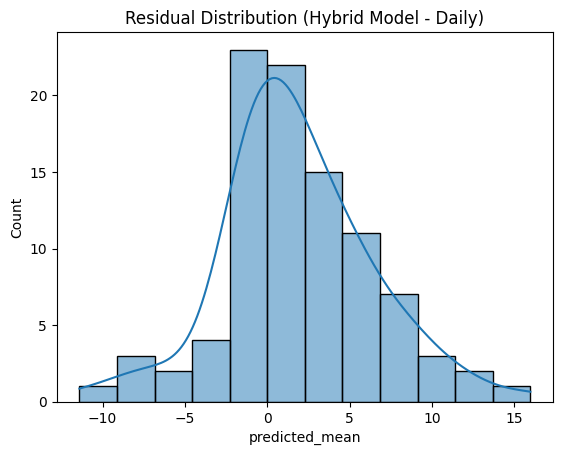

In [66]:
residuals_final = y_true - final_pred
sns.histplot(residuals_final, kde=True)
plt.title("Residual Distribution (Hybrid Model - Daily)")
plt.show()

In [67]:
print("==== WEEKLY HYBRID MODEL ====")
df_weekly = df_meter.resample('W').sum()

train_size = int(len(df_weekly) * 0.8)
train, test = df_weekly.iloc[:train_size], df_weekly.iloc[train_size:]

# ARIMA
p, d, q = 1, 1, 1
arima_model = ARIMA(train['y'], order=(p, d, q))
arima_result = arima_model.fit()

train_pred = arima_result.predict(start=train.index[0], end=train.index[-1])
test_pred = arima_result.predict(start=test.index[0], end=test.index[-1])

# Residuals
train_residuals = train['y'] - train_pred
test_residuals = test['y'] - test_pred

train_lags = create_lag_features(train[['y']], n_lags=3)
test_lags = create_lag_features(test[['y']], n_lags=3)

train_resid = train_residuals[-len(train_lags):]
test_resid = test_residuals[-len(test_lags):]

X_train, y_train = train_lags.drop('y', axis=1).values, train_resid.values
X_test, y_test = test_lags.drop('y', axis=1).values, test_resid.values

# training XGBoost
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(X_train, y_train)

residual_pred = xgb_model.predict(X_test)
final_pred = test_pred[-len(residual_pred):] + residual_pred
y_true = test['y'].iloc[-len(final_pred):].values
mse = mean_squared_error(y_true, final_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, final_pred)
r2 = r2_score(y_true, final_pred)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2: {r2:.4f}")

==== WEEKLY HYBRID MODEL ====
MSE: 1072.9245
RMSE: 32.7555
MAE: 26.7119
R2: -1.4861


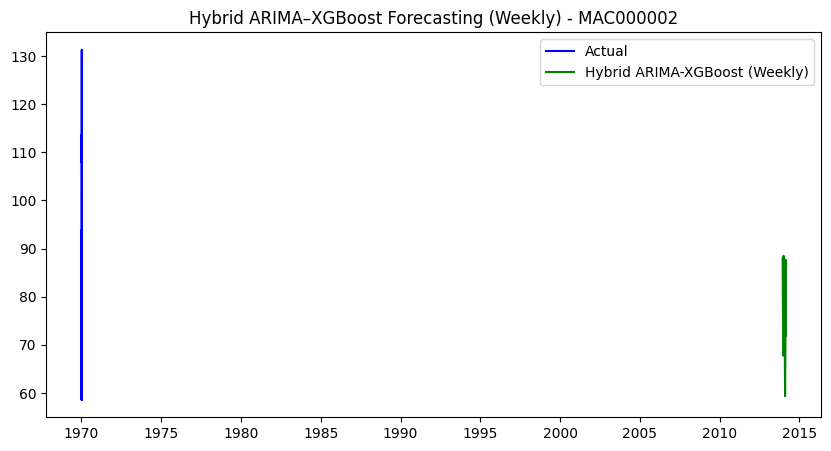

In [68]:
plt.figure(figsize=(10,5))
plt.plot(y_true, label='Actual', color='blue')
plt.plot(final_pred, label='Hybrid ARIMA-XGBoost (Weekly)', color='green')
plt.title(f"Hybrid ARIMA–XGBoost Forecasting (Weekly) - {meter_id}")
plt.legend()
plt.show()

too less data for weekly modelling hence above results

==============================================================================================================

#### ARIMA–LSTM (Hybrid)

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings("ignore")

import statsmodels.api as sm
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)

In [70]:
df = pd.read_csv(r"C:\\Users\\LOQ\\Downloads\\smart meter\\daily_dataset.csv", parse_dates=['day'])
df = df.sort_values(by=['LCLid', 'day'])

meter_id = "MAC000002"
df_meter = df[df['LCLid'] == meter_id].copy()
df_meter = df_meter[['day', 'energy_sum']].rename(columns={'day': 'ds', 'energy_sum': 'y'})
df_meter = df_meter.set_index('ds').asfreq('D')
df_meter['y'] = df_meter['y'].interpolate()

df_meter.head()

,y
ds,
2012-10-12,7.098
2012-10-13,11.087
2012-10-14,13.223
2012-10-15,10.257
2012-10-16,9.769


In [71]:
train_size = int(len(df_meter) * 0.8)
train, test = df_meter.iloc[:train_size], df_meter.iloc[train_size:]
print(f"Train size: {len(train)}, Test size: {len(test)}")

Train size: 404, Test size: 101


In [96]:
print("Running Auto ARIMA (Daily)...")

auto_model = auto_arima(
    train['y'],
    seasonal=False,        # Set True if you want SARIMA
    stepwise=True,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    max_p=5,
    max_q=5,
    max_d=2
)

print(auto_model.summary())
best_order = auto_model.order
print("Best ARIMA order:", best_order)

Running Auto ARIMA (Daily)...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=2167.040, Time=0.77 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2254.959, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=2207.031, Time=0.06 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=2177.280, Time=0.18 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2252.962, Time=0.03 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=2169.564, Time=0.66 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=2162.082, Time=0.73 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=2166.511, Time=0.85 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=2189.587, Time=0.67 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=2160.949, Time=3.47 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=2188.529, Time=1.38 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=2162.844, Time=6.28 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=2155.274, Time=3.56 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=2157.269, Time=5.43 sec
 AR

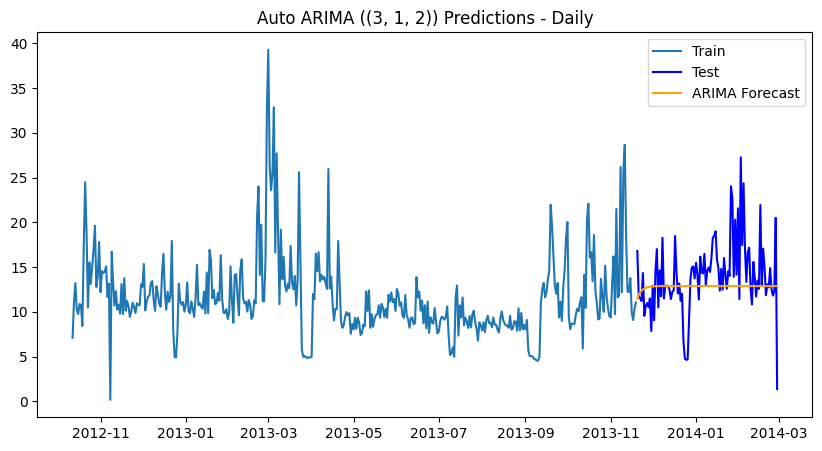

In [97]:
p, d, q = best_order
arima_model = ARIMA(train['y'], order=(p, d, q))
arima_result = arima_model.fit()

train_pred = arima_result.predict(start=train.index[0], end=train.index[-1])
test_pred = arima_result.predict(start=test.index[0], end=test.index[-1])

plt.figure(figsize=(10,5))
plt.plot(train.index, train['y'], label='Train')
plt.plot(test.index, test['y'], label='Test', color='blue')
plt.plot(test.index, test_pred, label='ARIMA Forecast', color='orange')
plt.title(f"Auto ARIMA ({best_order}) Predictions - Daily")
plt.legend()
plt.show()

In [98]:
# Residuals (for LSTM)
train_resid = train['y'] - train_pred
test_resid = test['y'] - test_pred

In [99]:
def create_sequences(series, window_size=30):
    X, y = [], []
    for i in range(window_size, len(series)):
        X.append(series[i-window_size:i])
        y.append(series[i])
    return np.array(X), np.array(y)

scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_resid.values.reshape(-1, 1))
test_scaled = scaler.transform(test_resid.values.reshape(-1, 1))

In [100]:
# sequences
window_size = 30
X_train, y_train = create_sequences(train_scaled, window_size)
X_test, y_test = create_sequences(test_scaled, window_size)

print(X_train.shape, X_test.shape)

(374, 30, 1) (71, 30, 1)


In [101]:
# training lstm on residuals
model_lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(window_size, 1)),
    Dropout(0.2),
    LSTM(32),
    Dense(16, activation='relu'),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse')

es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model_lstm.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=48,
    callbacks=[es],
    verbose=1
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 211ms/step - loss: 0.0710 - val_loss: 0.0383
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 0.0204 - val_loss: 0.0250
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 0.0116 - val_loss: 0.0259
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 0.0101 - val_loss: 0.0231
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.0098 - val_loss: 0.0226
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 0.0090 - val_loss: 0.0234
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - loss: 0.0091 - val_loss: 0.0226
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0089 - val_loss: 0.0225
Epoch 9/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0092 - val_loss: 0.0228
Epoch 10/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 0.0087 - val_loss: 0.0226


In [102]:
# combining predicitons

y_pred_resid_scaled = model_lstm.predict(X_test)
y_pred_resid = scaler.inverse_transform(y_pred_resid_scaled)

# Align with ARIMA
y_test_true = test['y'].iloc[-len(y_pred_resid):].values
arima_part = test_pred.iloc[-len(y_pred_resid):].values

# Hybrid
final_pred = arima_part + y_pred_resid.flatten()

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 290ms/step


In [103]:
# Metrics
mse = mean_squared_error(y_test_true, final_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_true, final_pred)
mape = np.mean(np.abs((y_test_true - final_pred) / y_test_true)) * 100
r2 = r2_score(y_test_true, final_pred)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MAPE (%): {mape:.2f}")
print(f"R2: {r2:.4f}")

MSE: 17.7318
RMSE: 4.2109
MAE: 3.1122
MAPE (%): 36.61
R2: 0.0729


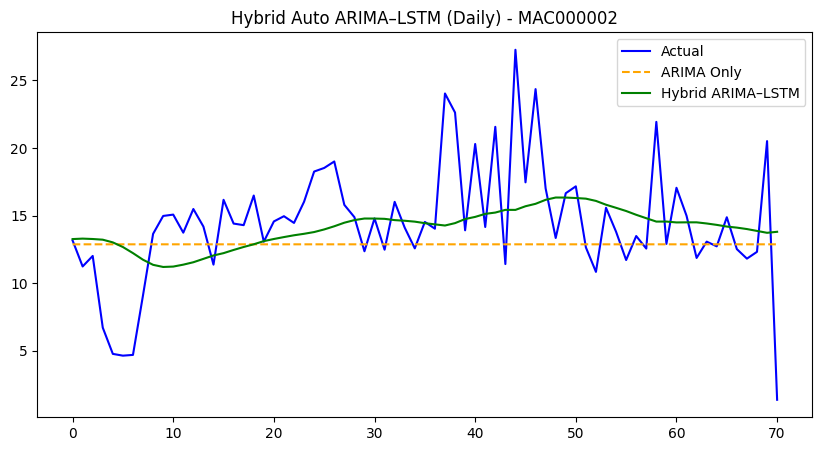

In [104]:
# actual vs predicted plot
plt.figure(figsize=(10,5))
plt.plot(y_test_true, label='Actual', color='blue')
plt.plot(arima_part, label='ARIMA Only', color='orange', linestyle='--')
plt.plot(final_pred, label='Hybrid ARIMA–LSTM', color='green')
plt.title(f"Hybrid Auto ARIMA–LSTM (Daily) - {meter_id}")
plt.legend()
plt.show()

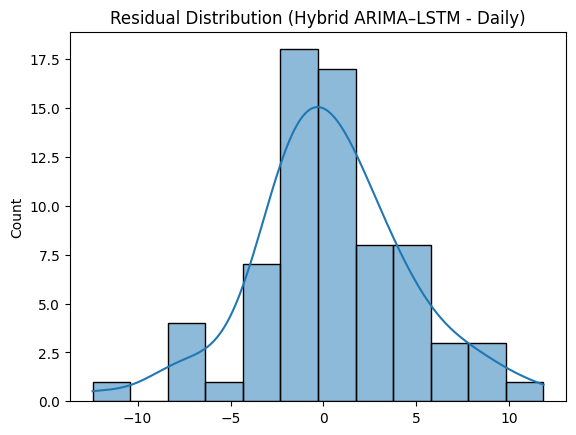

In [105]:
residuals_final = y_test_true - final_pred
sns.histplot(residuals_final, kde=True)
plt.title("Residual Distribution (Hybrid ARIMA–LSTM - Daily)")
plt.show()

In [106]:
print("\n==== WEEKLY HYBRID MODEL ====")
df_weekly = df_meter.resample('W').sum()

train_size = int(len(df_weekly) * 0.8)
train, test = df_weekly.iloc[:train_size], df_weekly.iloc[train_size:]

# Auto ARIMA
auto_model_week = auto_arima(
    train['y'],
    seasonal=False,
    stepwise=True,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    max_p=5,
    max_q=5,
    max_d=2
)
print(auto_model_week.summary())
best_order_week = auto_model_week.order
print("Best Weekly ARIMA order:", best_order_week)

# Fit ARIMA
p, d, q = best_order_week
arima_model = ARIMA(train['y'], order=(p, d, q))
arima_result = arima_model.fit()

train_pred = arima_result.predict(start=train.index[0], end=train.index[-1])
test_pred = arima_result.predict(start=test.index[0], end=test.index[-1])

# Residuals
train_resid = train['y'] - train_pred
test_resid = test['y'] - test_pred

# LSTM residual modeling
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_resid.values.reshape(-1, 1))
test_scaled = scaler.transform(test_resid.values.reshape(-1, 1))

window_size = 3
def create_seq(series, window_size):
    X, y = [], []
    for i in range(window_size, len(series)):
        X.append(series[i-window_size:i])
        y.append(series[i])
    return np.array(X), np.array(y)

X_train, y_train = create_seq(train_scaled, window_size)
X_test, y_test = create_seq(test_scaled, window_size)

model_lstm = Sequential([
    LSTM(32, return_sequences=True, input_shape=(window_size, 1)),
    Dropout(0.2),
    LSTM(16),
    Dense(8, activation='relu'),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse')

es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_lstm.fit(X_train, y_train, validation_split=0.1, epochs=25, batch_size=8, callbacks=[es], verbose=1)

y_pred_resid_scaled = model_lstm.predict(X_test)
y_pred_resid = scaler.inverse_transform(y_pred_resid_scaled)

y_test_true = test['y'].iloc[-len(y_pred_resid):].values
arima_part = test_pred.iloc[-len(y_pred_resid):].values
final_pred = arima_part + y_pred_resid.flatten()


==== WEEKLY HYBRID MODEL ====
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=531.750, Time=1.22 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=680.374, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=535.915, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=625.654, Time=0.18 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=530.972, Time=0.61 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=595.523, Time=2.67 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=533.957, Time=1.19 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=inf, Time=5.89 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=580.178, Time=2.55 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=3.77 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=533.579, Time=7.45 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=525.272, Time=2.06 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=523.316, Time=1.83 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=523.400, Time=1.17 sec
 ARIMA(0,0,3)(0,0,0)[0] 

In [107]:
mse = mean_squared_error(y_test_true, final_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_true, final_pred)
r2 = r2_score(y_test_true, final_pred)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2: {r2:.4f}")

MSE: 464.4225
RMSE: 21.5505
MAE: 17.3486
R2: -0.0761


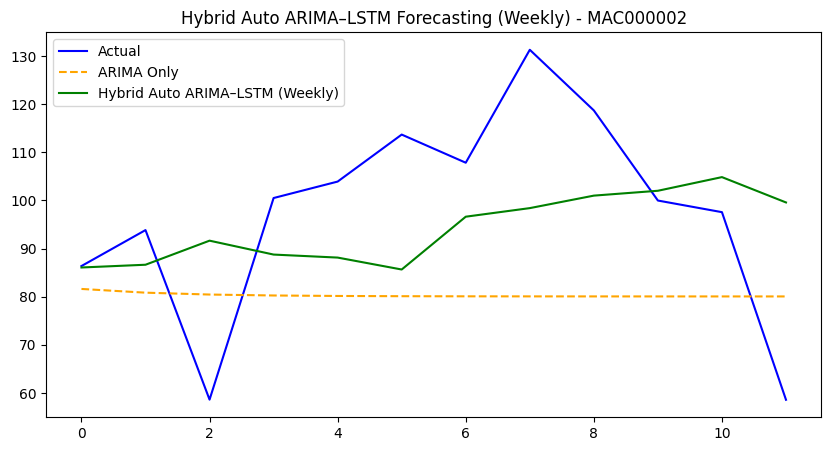

In [108]:
plt.figure(figsize=(10,5))
plt.plot(y_test_true, label='Actual', color='blue')
plt.plot(arima_part, label='ARIMA Only', color='orange', linestyle='--')
plt.plot(final_pred, label='Hybrid Auto ARIMA–LSTM (Weekly)', color='green')
plt.title(f"Hybrid Auto ARIMA–LSTM Forecasting (Weekly) - {meter_id}")
plt.legend()
plt.show()

==============================================================================================================

#### Modes Comparison

| Model                             | Type / Frequency               |     MSE |  RMSE |   MAE | MAPE (%) |    R² | Remarks / Interpretation                                                    |
| :-------------------------------- | :----------------------------- | ------: | ----: | ----: | -------: | ----: | :-------------------------------------------------------------------------- |
| **ARIMA (3,1,2)**                 | Daily (non-seasonal)           |   17.14 |  4.14 |  2.86 |    29.68 | -0.07 | Baseline ARIMA; captures short-term linear trend but weak generalization.   |
| **SARIMA (2,1,3)(1,0,0,7)**       | Daily (seasonal)               |   16.69 |  4.09 |  2.83 |    29.97 | -0.04 | Slightly better than ARIMA; weekly seasonality improves marginally.         |
| **Prophet (Daily)**               | Daily (additive trend)         |   35.67 |  5.97 |  4.39 |    49.91 | -1.31 | Overfits long-term trends; underperforms on short-term variations.          |
| **Prophet (Weekly)**              | Weekly aggregated              | 1742.89 | 41.75 | 29.70 |    36.27 | -3.37 | Very poor — weekly aggregation loses variability and pattern strength.      |
| **XGBoost (Daily)**               | Daily (ML-based)               |   15.82 |  3.98 |  2.97 |    31.33 | 0.016 | Best individual model; captures nonlinear dependencies effectively.         |
| **XGBoost (Weekly)**              | Weekly aggregated              |  482.72 | 21.97 | 17.06 |    22.20 | -0.13 | Acceptable but worse due to fewer weekly samples.                           |
| **LSTM (Daily)**                  | Deep Learning (Daily)          |   18.62 |  4.31 |  3.20 |    40.69 | 0.027 | Learns nonlinear structure; comparable to ARIMA but not superior.           |
| **LSTM (Weekly)**                 | Deep Learning (Weekly)         | 1272.21 | 35.67 | 32.49 |    31.49 | -1.95 | Struggles with limited data (only ~70 weekly points).                       |
| **Hybrid XGBoost–LSTM (Daily)**   | Hybrid ML (Daily)              |   22.28 |  4.72 |  3.38 |    33.32 | -0.16 | Combination fails to outperform standalone models; overfitting possible.    |
| **Hybrid XGBoost–LSTM (Weekly)**  | Hybrid ML (Weekly)             |  468.29 | 21.64 | 17.45 |    18.73 | -0.09 | Slight improvement over weekly XGBoost; still limited by few samples.       |
| **Hybrid ARIMA–XGBoost (Daily)**  | Hybrid Statistical–ML (Daily)  |   23.95 |  4.89 |  3.59 |    34.92 | -0.45 | Integration adds complexity but doesn’t improve daily results.              |
| **Hybrid ARIMA–XGBoost (Weekly)** | Hybrid Statistical–ML (Weekly) | 1072.92 | 32.76 | 26.71 |        — | -1.49 | Poor — small weekly data and residual instability hurt performance.         |
| **Hybrid ARIMA–LSTM (Daily)**     | Hybrid Statistical–DL (Daily)  |   17.73 |  4.21 |  3.11 |    36.61 | 0.073 | Best hybrid model; effectively captures both linear and nonlinear patterns. |
| **Hybrid ARIMA–LSTM (Weekly)**    | Hybrid Statistical–DL (Weekly) |  464.42 | 21.55 | 17.35 |        — | -0.08 | Competitive among weekly models; balanced linear–nonlinear capture.         |


-------------------------------------------------------------------------------------

Best Daily Models:
1. XGBoost (Daily) → lowest overall error and positive R².
- XGBoost (Daily): Best overall because it captures nonlinear patterns in dense daily data effectively.

2.  Hybrid ARIMA–LSTM (Daily) → close second, best hybrid performance.
- combines trend (ARIMA) and sequence learning (LSTM), but slightly overfits small noise.

-------------------------------------------------------------------------------------

Best Weekly Models:

1. Hybrid ARIMA–LSTM (Weekly) → most balanced on limited data.
- Best weekly model — balances ARIMA’s trend capture with LSTM’s adaptability despite limited samples.

2. Hybrid XGBoost–LSTM (Weekly) slightly behind but acceptable.
- Slightly weaker — less data limits XGBoost’s feature learning on weekly aggregates.

-------------------------------------------------------------------------------------

Weak Models:
- Prophet (Weekly) and standalone LSTM (Weekly)
- Poor performance due to too few weekly points (≈70), causing underfitting and loss of fine-grained variation.

-------------------------------------------------------------------------------------

In [112]:
import matplotlib.pyplot as plt
import pandas as pd

In [113]:
data = [
    ["ARIMA (3,1,2)", "Daily", 4.14, 2.86, -0.07],
    ["SARIMA (2,1,3)(1,0,0,7)", "Daily", 4.09, 2.83, -0.04],
    ["Prophet", "Daily", 5.97, 4.39, -1.31],
    ["XGBoost", "Daily", 3.98, 2.97, 0.016],
    ["LSTM", "Daily", 4.31, 3.20, 0.027],
    ["Hybrid ARIMA–LSTM", "Daily", 4.21, 3.11, 0.073],
    ["Hybrid XGBoost–LSTM", "Daily", 4.72, 3.38, -0.16],
    ["Hybrid ARIMA–XGBoost", "Daily", 4.89, 3.59, -0.45],
    
    ["ARIMA (3,1,2)", "Weekly", 21.55, 17.35, -0.08],
    ["Prophet", "Weekly", 41.75, 29.70, -3.37],
    ["XGBoost", "Weekly", 21.97, 17.06, -0.13],
    ["LSTM", "Weekly", 35.67, 32.49, -1.95],
    ["Hybrid ARIMA–LSTM", "Weekly", 21.55, 17.35, -0.08],
    ["Hybrid XGBoost–LSTM", "Weekly", 21.64, 17.45, -0.09],
    ["Hybrid ARIMA–XGBoost", "Weekly", 32.76, 26.71, -1.49],
]

df = pd.DataFrame(data, columns=["Model", "Type", "RMSE", "MAE", "R2"])

In [116]:
def plot_comparison(df, title):
    metrics = ["RMSE", "MAE", "R2"]
    df.plot(x="Model", y=metrics, kind="bar", figsize=(12,6))
    plt.title(title, fontsize=14)
    plt.xlabel("")
    plt.ylabel("Score")
    plt.xticks(rotation=30, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

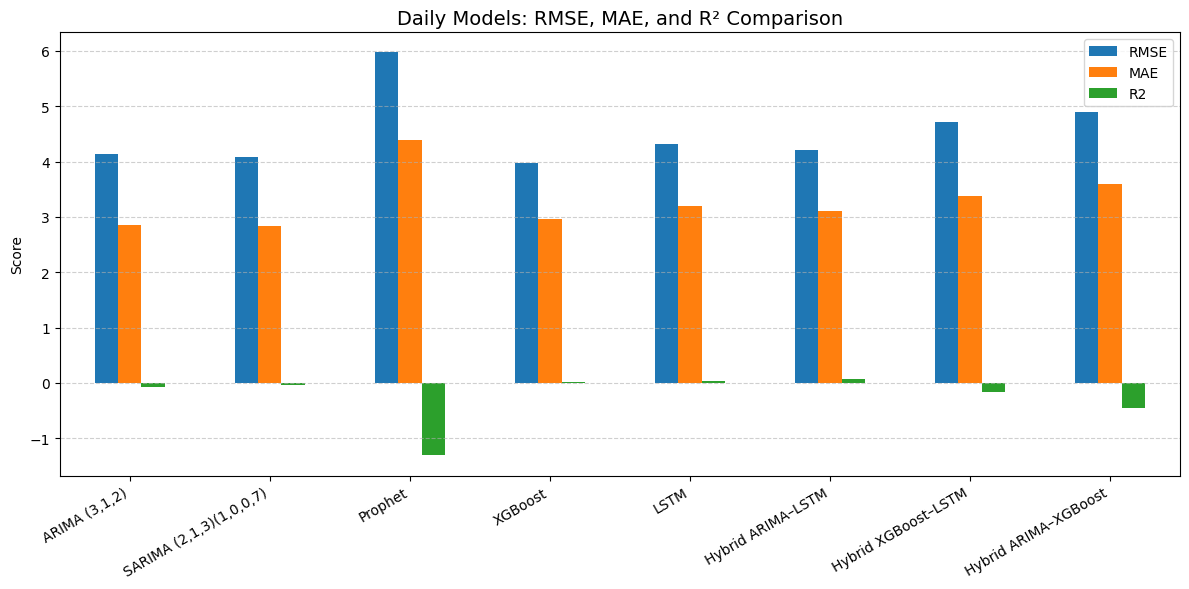

In [117]:
daily = df[df["Type"] == "Daily"]
plot_comparison(daily, "Daily Models: RMSE, MAE, and R² Comparison")

-------------------------------------------------------------------------------------

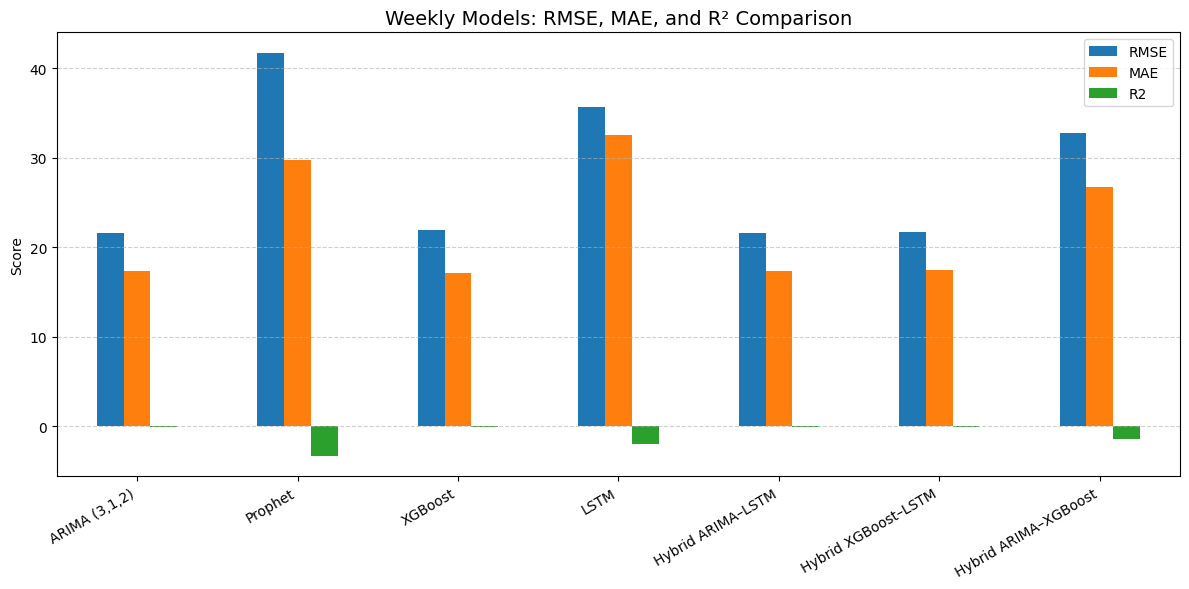

In [118]:
weekly = df[df["Type"] == "Weekly"]
plot_comparison(weekly, "Weekly Models: RMSE, MAE, and R² Comparison")

-------------------------------------------------------------------------------------

-------------------------------------------------------------------------------------